---
> 「中学生までは勉強嫌いで、何のために勉強しているのかほとんど理解していませんでした。」  
>天野浩(85年に青色LEDの材料となるGaNの透明結晶製造に成功)
---

# GANとは

Generative Adversarial Network（敵対的生成ネットワーク）と呼ばれるDNNモデルの一種
- 入力データの特徴を学習し、結果的に存在するデータの特徴をとらえた実在しないデータを生成することができる
- GANは、Generator（生成ネットワーク）とDiscriminator（識別ネットワーク）で構成され、互いに競い合わせながら学習を進める
  - 贋作者（Generator）と鑑定士（Discriminator）で競争させて学習させることから敵対的と呼ばれる
  - この競い合わせるというのが重要で、片側だけが先走って学習が進むと失敗する
  - 学習する際には、「少し難しい内容を次々と学ぶ」ことが重要で「いきなり高度な内容は学習できない」ということを意味しており、人間と同じである
  - 実際には、本物のデータと偽物のデータを交互に与えるなどして、判定させる


## GANの特徴

GANが使われるシーンは、例えば、
- 誰かに似せた**自然な**絵を自動で描かせたい
- よくある**偽物とわかりにくい**フェイク画像や動画、音声などを作らせたい
- **あたかもそこにありそうなもの**をないところから追加したい
- 逆にあって邪魔なものを**あたかもなかったかのように自然に**消し去りたい

といった用途が思い当たる

簡単に共通するのは、
- 人間が判断して違和感がなく自然であること
- 自由に生成できること

であろう

この魔法を実現するような内容から、AI関連で話題をさらうのは主にGAN応用であることもうなずける

GANでは2つのモデルを競合させるように学習させる**巧妙**な手法である

GANのその他の特徴として、次のような点を挙げることができる
- 教師なし学習が可能
- データのラベリングが不要
  - というか、そういう問題を扱うことが得意
- ラベリングが無いため学習が不安定になりやすい
  - 学習を安定させる工夫が必要で、様々提案されている

## DiscriminatorとGenerator

DiscriminatorとGeneratorという2つのモデルを贋作者と鑑定士にたとえたが、この対立する目的を持つモデル同士を競わせる過程をAdversarial(敵対的) Processと呼ぶ

<img src="http://class.west.sd.keio.ac.jp/dataai/text/ganfig.png" width=500>

Generatorは一様分布や正規分布などからサンプリングしたノイズベクトル$z$をもとに、アップサンプリングして画像を生成する
- この辺りが何を言っているか？というのが最初はつかみにくいかもしれない
- やりたいことは、「自由に生成できること」であるため、この「自由に」を表現するには乱数がどうしても必要となる
  - つまり、乱数としての潜在空間から何かが作れたら、「自由な生成」を実現できるという発想

一方、Discriminatorは単純な分類問題を解くネットワークでGeneratorが生成した画像と本物の画像を分類する

この２つのネットワークを交互に学習すれば、Generatorは本物のデータに近いデータを生成するようになる

特に、Generatorの入力が乱数で、かつ、DiscriminatorはReal画像と、Generator画像(偽画像)を交互(もしくはランダムに)受け付けて、出力はその真偽のみという構成を持つ

もちろん、これだけではうまく動作しない


## DiscriminatorとGeneratorの目的

Discriminatorの目的は明瞭で、予測値と実際の値が一致すればよく、より具体的にはデータを適切に分類する決定境界を見つけることが目標である

しかしながら、Generatorは、乱数だけ入力され、それに対して勝手に生成した謎なデータを出力し、その出力が妥当なデータでなければならない
- つまり、Generatorは**正解となる出力値がない**状況で、妥当な出力を出す必要がある
- これでは、学習は進まず、何か目的・目標が必要となる

Generatorは、**データに近いモデル分布を見つける**ことを目標とする

- すなわち、Generatorは「今観測できているデータは、なんらかの確率分布に基づいて生成されている」という仮定に基づき、データを生成する確率分布そのものをモデル化しようと試みることであるといえる


## GANの定式化

定式化にあたり、先ほどの図における入力としてのDataset、乱数、判定結果を次のように定める

<img src="http://class.west.sd.keio.ac.jp/dataai/text/gan1.svg" width=500>

このように定めると、Datasetとしての入力の確率変数$x$に対して、Discriminatorに入力されるReal dataの分布$p_d(x)$と、Fake dataの分布$p_g(x)$、これらの2つの確率分布の「距離」を近づけることを目的とするといえる

もちろんであるが、Generatorは明確に$x$の入力を持っておらず、その分布は明示的に与えられていない
- よって、例えば生成結果とデータ分布との尤度を直接計算するなどして、生成結果とデータ分布との近さを測るなどということはできない



### Discriminatorの定式化

では、実際にDiscriminatorに入力されるデータ分布$p_d(x)$を求めるとはどういうことか？

GANでは直接尤度を測る代わりに、リアルデータの分布$p_d(x)$とフェイクデータの分布$p_g(x)$の密度比$r(x)$を考える
$$
r(x) = \frac{p_d(x)}{p_g(x)}
$$

ここで、データ分布あるいはモデル分布から生成されたラベル付きのデータ集合$\{(x1,y1),⋯,(xN,yN)\}$を考え、データ分布により生成されたデータのラベルをy=1、モデル分布により生成されたデータのラベルをy=0とすると、それぞれの分布は次のように表される

$$
p_d(x) = p(x|y = 1)\\
p_g(x) = p(x|y = 0)
$$

この時、密度比$r(x)$はベイズの式により次のように表すことができる

$$
\begin{align}
r(x) &= \frac{p(x|y = 1)}{p(x|y = 0)}\\
&= \frac{p(y = 1| x)p(x)}{p(y=1)}\cdot\frac{p(y=0)}{p(y=0|x)p(x)}
\end{align}
$$

ここで、$\pi = p(y=1)$とすると、
$$
\begin{align}
r(x) &= \frac{p(y = 1|x)}{p(y = 0| x)}\cdot\frac{1-\pi}{\pi}
\end{align}
$$

となる

$\pi$は実際のデータ数の比で近似できる
- 実際には$1/2$になるため、
$$
\begin{align}
r(x) &= \frac{p(y = 1|x)}{p(y = 0| x)}
\end{align}
$$
としてよい

ラベルは$y=0$か$y=1$のみであるため、$p(y=1∣x)$を推定できれば、密度比$r(x)$が求まる
- そこで、$p(y=1∣x)$を近似する分布を、例えばNNを用いて求めることを考えて、パラメータ$\varphi$を用いて$q_\varphi(y=1∣x)$とする

これを式で書くと

$$
p(y = 1| x) \approx q_\varphi(y = 1| x)
$$
となる

$q_\varphi(y = 1| x)$を見出すモデルをDiscriminatorと呼び、$D(\phi; x)$と表す
- 本来密度比を考える問題が、分類問題と同じ確率的分類器の最適化問題に置き換わった

この最適化に用いる誤差関数$U(D)$は、例えば、交差エントロピーを想定すれば、
$$
U(D) = -E_{p(x,y)}[y \ln D(\phi; x) + (1-y) \ln (1-D(\phi; x))]
$$
として平均を考えればよい

これを変形すると、
$$
\begin{align}
U(D) &= -E_{p(x,y)}[y \ln D(\phi; x) + (1-y) \ln (1-D(\phi; x))]\\
&= -E_{p(x|y)p(y)}[y \ln D(\phi; x) + (1-y) \ln (1-D(\phi; x))]\\
&= -E_{p(x|y=1)p(y=1)}[\ln D(\phi; x)] + E_{p(x|y=0)p(y=0})[ \ln (1-D(\phi; x))]\\
&= \pi \cdot E_{p_d(x)}[\ln D(\phi;x)]+(1-\pi)\cdot E_{p_g(x)}[\ln (1-D(\phi;x))]
\end{align}
$$

となる

各ラベルのデータを与えるとき、データが丁度同数ずつ混ざっていれば、y=0およびy=1となるラベルのデータ数が等しい場合$\pi = \frac{1}{2}$となることから、Discriminatorの目的関数$V(D)$は、

$$
V(D) = E_{p_d(x)}[\ln D(\phi;x)]+E_{p_g(x)}[\ln (1-D(\phi;x))]
$$

となり、これが最大となるように訓練することになる

### Generatorの定式化

潜在変数$z$を仮定すると、

$$
p_g(x) = \int{p(x|z)p(z)}dz
$$

となる

先ほどと同様に、$p(x|z)$を近似する分布として$q_\theta(x|z)$を導入すると

$$
p(x|z) \approx q_\theta(x|z)
$$

となる

この$q_\theta(x|z)$を推定するモデルをGeneratorと呼び$G(\theta;z)$と表す

Generatorの目的関数は、Discriminator $D(\varphi;x)$について最適なDiscriminator $D^*(\varphi;x)$が得られたとすると、

$$
V(D^*, G) = E_{p_d(x)}[\ln D^*(x)]+E_{p(z)}[\ln (1-D^*(G(\theta;z))]
$$

となる

この初項はデータセットのみに依存して、$z$に依存していない
- よって、定数と考えてよいため、結果的に、

$$
V(D^*, G) = E_{p(z)}[\ln (1-D^*(G(\theta;z))]
$$

とみなしてよい

つまり、Generatorは、この$V(D^*, G)$を最小化することが目的となる




### GAN全体の定式化

さて、実際に用いる目的関数は次の通りとなる

Discriminatorは、Generator$G(\theta;z)$を固定したうえで、
$$
\mathop{\rm max}\limits_{\phi}
E_{p_d(x)}[\ln D(\phi;x)]+E_{p(z)}[\ln (1-D(\phi;G(\theta;z))]
$$
を計算する

Generatorは、Discriminator$D(\phi;x)$を固定したうえで、
$$
\mathop{\rm min}\limits_{\theta}
E_{p(z)}[\ln (1-D(\phi;G(\theta;z))]
$$

を計算する

DとGは包含関係にあり、このことがいわゆる2つのネットワークを互いに競わせるように学習するという意味である

より簡潔には、
$$
\mathop{\rm min}\limits_{G}\mathop{\rm max}\limits_{D} V(D, G)
$$
と表すことができ、学習が進むと、生成器$G(\theta;z)$が生成するデータは、実際のデータに近くなる


## GANのロスについて

GANはDを騙すように訓練することでGの訓練が進む
- DやGの一方（特にD）が強すぎるとGの訓練が止まる
- DとGの損失ギャップが少ないほど訓練が進みやすい

つまりお互いにロスが拮抗するように学習が進むとよく、片方が強くなりすぎ、ロスが乖離するとうまくいかない
- 特によく見受けられるのはGよりDが強くなり、途中からGの学習が進まずDを騙すことができなくなるケース

## GANの評価指標

GANは教師なし学習であり、教師あり学習で用いられるAccuracy, F1 scoreといった評価指標がない

妥協案として、次の2つがしばしば利用されるが、学習済みモデルを利用するため面倒である
- したがって、BCEロスや、L1ロス(平均絶対値誤差)を用いたりすることも普通に行われている

### Frechet Inception Distance(FID:フレシェ・インセプション距離)

生成された画像の分布と元の画像の分布がどれだけ近いかを測る指標があればよいが、この近さをどのように表現するかが問題となる

そこで、人間を超える画像認識精度をもつようになった機械学習モデルを用い、画像を低次元の潜在空間で表現し、その空間で距離を測るというコンセプト

実際には、Inception V3の事前トレーニング済みモデルを使用し、実画像と偽画像の特徴ベクトルを抽出する

具体的には次の式で求める
- なお、m,cは埋め込み空間上での平均ベクトルおよび共分散行列
- 添字wは生成画像を意味し、何もついていないものは実画像を意味する
- 距離を表すため、値は小さいほど実画像に近いことを意味し、Generator性能がより優れていることを示す
- 実画像の特徴ベクトル$X$および生成画像の特徴ベクトル$Y$の平均を$\mu_X$、$\mu_Y$、それらの共分散行列を$\Sigma_X$、$\Sigma_Y$と表す
- $\mathrm{Tr}$は行列のトレース(対角成分の和)を表す
- $(\Sigma_X\Sigma_Y)^{1/2}$は行列の平方根であり、2乗すると$\Sigma_X\Sigma_Y$になる行列を意味する

$$
FID = ||\mu_X-\mu_Y||^2_2+\mathrm{Tr}\left(\Sigma_X+\Sigma_Y-2(\Sigma_X\Sigma_Y)^{1/2}\right)
$$

なお、本来フレシェ距離は2つの「多変量」正規分布間の距離を計算するために利用

要するに、Inception-v3が生成した潜在空間上でどこにいるかが問題で、これがちかければよいんだよ、という発想
- これでよいのか？というのは当然ある
- Inception-V3に基づくが、「そのモデルが評価に最適である」「他にもっと良いモデルはない」という保証はない
- みんなが使っていて、それなりに評価上よいからこれでよいということになっている

ではなぜ、FIDを利用するのか？
- まずは、多様性を持たすことができる指標であるということ
  - これはGANが学習中に似た画像ばかり生成するようになる「モード崩壊」を検出し、対策を評価するため
  - 実際、FIDはモード崩壊も含めて、実画像の分布との違いとして見つける助けになり、実際にそのことも示されている
  - ただし、FIDを計算するだけでモード崩壊を防げるわけではなく、値が悪化しても、多様性不足なのか画像品質の低下なのかは、区別できない
- GANの学習成果を、共通の物差しで数値比較するため
  - もちろんそうであるが、これだけでは、他の指標でもよい
- 画素の違いより、画像の内容に関わる違いを計測する
  - その画像が持つ特徴が対象画像の特徴と似ているかの検証ができる
- 生成画像だけでなく、実画像を基準にしたい。
  - 従来利用されていたInception Scoreは、分類の確信度とクラスの多様さを見ますが、実画像の分布をみているわけではありませんでした
  - FIDは実画像との平均・共分散のずれを見るため、品質の低下と多様性の不足を、どちらも評価に反映できる可能性があり、実際実験でもそれを確認できます
  - ノイズやぼかしなどの劣化を、Inception Scoreより一貫して捉えたという実験結果があります
- 分布の比較を、扱いやすい計算にしたい。
  - 特徴量の複雑な分布をそのまま比較することは避けたいです
  - 平均と共分散で正規分布に近似し、これを距離で計算できるという便利な手法です
  - 情報を落とす代わりに、計算を実用的にしたといえます

これについては、後で詳細に解析する

### Perceptual Path Length(PPL)

人間の感覚、つまり視覚・知覚的に潜在空間上で画像が滑らかに変化するかを表す指標

FIDと同様に学習済みモデルにおける潜在空間での距離を利用する

- 画像を生成する種となる潜在空間上で、画像の変化は『知覚的』に短距離で変化しているか」を表す指標
  - モーフィングのようにずれることなくダイレクトかつまっすぐに変化すれば小さな値をとるため、潜在空間がどれだけ適切に構築されているかを評価できる

- 例えば画像認識モデルであるVGGを使用し、その上での特徴量ベクトルの距離を用いる

解析的に求めることができないため、多くの画像を用意し、実際に距離を求めて平均値を算出することでPPLを得る

- この値が小さいほど潜在空間が知覚的に滑らかであることを意味する

# GANの実際

MNISTを用いて、MNISTっぽいデータを生み出すGANを構成する
- 似た動作を行うAutoEncoderとも比較するとよい

今回は正確にはGeneratorとDiscriminatorに畳み込みニューラルネットを利用しており、**DCGAN(Deep Convolutional Generative Adversarial Networks)**と呼ばれる

今回の実装におけるDiscriminatorとGeneratorは次の通りである

**Discriminator**

一般的な畳み込みニューラルネットワークを利用している
- ただし、MaxPoolingを使わずにstride=2として画像サイズを半分にする

**Generator**
入力$z$は62次元の乱数ベクトル、これをシードとして画像を生成する

最初に全結合網を用いてサイズを拡大する
- 6272次元まで拡張し$7\times 7\times 128$のテンソルに変換
- ConvTranspose2Dでチャネルを減らしつつ、画像サイズをMNISTの$28 \times 28$ピクセルまで拡張する
- 出力は1チャンネル$28 \times 28$ピクセルの画像となる



In [1]:
cuda = "cuda:0"
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
device = torch.device(cuda if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


ハイパーパラメータは次の通り

In [2]:
# hyperparameters
batch_size = 128
lr = 0.0002
z_dim = 62
num_epochs = 25
sample_num = 16
log_dir = './logs'

MNISTデータの読み込みとDataLoaderの設定

今回は、訓練用とテスト用に分ける必要はない

In [3]:
transform = transforms.ToTensor()
dataset = datasets.MNIST('data/mnist', train=True, download=True, transform=transform)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]


## GeneratorとDiscriminatorの定義

GeneratorとDiscriminatorの定義は次のようになる
- 同様に似たようなデータを作り出す方法としてAutoEncoderを学んだ
- AEでは基本的にEncoderとDecoderは対称形とするが、GANでは目的が異なるため異なる構造になる



In [4]:
class Generator(nn.Module):
  def __init__(self):
    super(Generator, self).__init__()
    self.fc = nn.Sequential(
      nn.Linear(62, 1024),
      nn.BatchNorm1d(1024),
      nn.ReLU(),
      nn.Linear(1024, 128 * 7 * 7),
      nn.BatchNorm1d(128 * 7 * 7),
      nn.ReLU(),
    )
    self.deconv = nn.Sequential(
      nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
      nn.Sigmoid(),
    )
    initialize_weights(self)
  def forward(self, input):
    x = self.fc(input)
    x = x.view(-1, 128, 7, 7)
    x = self.deconv(x)
    return x

class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
      nn.LeakyReLU(0.2),
      nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
      nn.BatchNorm2d(128),
      nn.LeakyReLU(0.2),
    )
    self.fc = nn.Sequential(
      nn.Linear(128 * 7 * 7, 1024),
      nn.BatchNorm1d(1024),
      nn.LeakyReLU(0.2),
      nn.Linear(1024, 1),
      nn.Sigmoid(),
    )
    initialize_weights(self)
  def forward(self, input):
    x = self.conv(input)
    x = x.view(-1, 128 * 7 * 7)
    x = self.fc(x)
    return x

### ウェイトの初期化

これまであまり問題としなかったが、GANでは学習を安定的に進めるために様々な工夫がなされた経緯がある
- その一つがウェイトの初期化である
- ただし、現時点で必須の方法というわけでも、一般的な方法というわけではない
  - 特に何もしなくてもよい
- 一方で、パラメタ初期化の違いで学習結果に違いが出る可能性もあり、ここでまとめて扱う

まず、PyTorchのパラメーター初期化について簡単に説明する

これまでは、Noneとしてゼロ初期化のみ議論してきた

パラメータ(重み)は`nn.Linear()`などとしたときに設計され(インスタンス化した時に実体ができる)、その値はインスタンス化した後weightメソッドを使うことで見ることができる
```
linear = nn.Linear(5, 2)
linear.weight
```
また、逆にweightに対してnn.init の中のメソッドを適用すれば初期化できる

この初期化においては、次のような分布や定数の利用が想定できるので、例を示す

- 正規分布:`normal_(weight, mean, std)`
```
linear = nn.Linear(5, 2)
nn.init.normal_(linear.weight, 0.0, 1.0)
```
- 一様分布:`uniform_(weight, a, b)`
```
linear = nn.Linear(5, 2)
nn.init.uniform_(linear.weight, 0.0, 1.0)
```

- 定数:`constant_(weight, c)`
```
linear = nn.Linear(5, 2)
nn.init.constant_(linear.weight, 1.0)
```

- Xavierの初期値:`xavier_normal_(weight, gain=1)`
```
linear = nn.Linear(5, 2)
nn.init.xavier_normal_(linear.weight)
```

- Heの初期値
```
kaiming_normal_(weight, a=0, mode='fan_in', nonlinearity='leaky_relu')
linear = nn.Linear(5, 2)
nn.init.kaiming_normal_(linear.weight)
```

その効果とより詳しい説明はこのテキストの末尾に示す


### Discriminatorのウェイトの初期化について、

ここでは、全て正規分布で初期化しており、専用の関数(メソッド)を定義している
- Discriminatorクラスから呼び出される

In [5]:
def initialize_weights(model):
  for m in model.modules():
    if isinstance(m, nn.Conv2d):
      m.weight.data.normal_(0, 0.02)
      m.bias.data.zero_()
    elif isinstance(m, nn.ConvTranspose2d):
      m.weight.data.normal_(0, 0.02)
      m.bias.data.zero_()
    elif isinstance(m, nn.Linear):
      m.weight.data.normal_(0, 0.02)
      m.bias.data.zero_()

### ネットワークのインスタンス化とオプティマイザの指定
- 今回はAdamで、ハイパーパラメタは微妙にチューニングしている
- また、ロス関数は真偽のみを議論するためバイナリクロスエントロピーを用いる

In [6]:
G = Generator().to(device)
D = Discriminator().to(device)
G_optimizer = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
D_optimizer = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

## 実際の処理内容

コードを見ると実際何をしているかがよくわかる
- ここではFIDは利用していない

In [7]:
def train(D, G, criterion, D_optimizer, G_optimizer, data_loader):
  # 訓練モードへ
  D.train()
  G.train()
  # 本物ラベルは1
  y_real = Variable(torch.ones(batch_size, 1))
  # 偽物ラベルは0
  y_fake = Variable(torch.zeros(batch_size, 1))
  y_real = y_real.to(device)
  y_fake = y_fake.to(device)
  D_running_loss = 0
  G_running_loss = 0
  for batch_idx, (real_images, _) in enumerate(data_loader):
    # 一番最後のデータがバッチサイズに満たない場合は無視してエラーを避ける
    if real_images.size()[0] != batch_size:
      break
    # 潜在変数としての入力(変な言い方だが)を乱数で初期化
    z = torch.rand((batch_size, z_dim))
    real_images, z = real_images.to(device), z.to(device)
    # Discriminatorの勾配の初期化
    D_optimizer.zero_grad()
    # Discriminatorは実画像データを1=Trueと認識するほどよい
    D_real = D(real_images)
    D_real_loss = criterion(D_real, y_real)
    # DiscriminatorはGeneratorが生成した偽画像を0=Falseと認識するほどよい
    # fake_imagesをDiscriminatorが学習しないようにdetach()する
    fake_images = G(z)
    D_fake = D(fake_images.detach())
    D_fake_loss = criterion(D_fake, y_fake)
    # 2つのlossの和を最小化する
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()  # Dだけ更新(Gのパラメータは更新しない)
    D_running_loss += D_loss.data.item()
    # Generatorの更新
    G_optimizer.zero_grad()
    # GeneratorにとってGeneratorが生成した画像の認識結果は1(本物)に近いほどよい
#    fake_images = G(z)
    D_fake = D(fake_images)
    G_loss = criterion(D_fake, y_real)
    G_loss.backward()
    G_optimizer.step()
    G_running_loss += G_loss.data.item()
  D_running_loss /= len(data_loader)
  G_running_loss /= len(data_loader)
  return D_running_loss, G_running_loss

### 途中結果の確認

学習途中で、お試しに画像を保存するため、適当な$z$から画像を生成させる

In [8]:
def generate(epoch, G, log_dir='logs'):
  G.eval()
  if not os.path.exists(log_dir):
    os.makedirs(log_dir)
  # 生成のもとになる乱数を生成
  sample_z = torch.rand((64, z_dim))
  sample_z = sample_z.to(device)
  # Generatorでサンプル生成
  samples = G(sample_z).data.cpu()
  save_image(samples, os.path.join(log_dir, 'epoch_%03d.png' % (epoch)))

## 学習

実際にGANを学習させる
- 10分程度必要

In [9]:
history = {}
history['D_loss'] = []
history['G_loss'] = []
for epoch in range(num_epochs):
  D_loss, G_loss = train(D, G, criterion, D_optimizer, G_optimizer, data_loader)
  print('epoch %d, D_loss: %.4f G_loss: %.4f' % (epoch + 1, D_loss, G_loss))
  history['D_loss'].append(D_loss)
  history['G_loss'].append(G_loss)
  # 特定のエポックでGeneratorから画像を生成してモデルも保存
  if (epoch+1)%5 == 0:
    generate(epoch + 1, G, log_dir)
    torch.save(G.state_dict(), os.path.join(log_dir, 'G_%03d.pth' % (epoch + 1)))
    torch.save(D.state_dict(), os.path.join(log_dir, 'D_%03d.pth' % (epoch + 1)))
# 学習履歴を保存
with open(os.path.join(log_dir, 'history.pkl'), 'wb') as f:
  pickle.dump(history, f)

epoch 1, D_loss: 0.8590 G_loss: 1.2946
epoch 2, D_loss: 1.0339 G_loss: 1.1378
epoch 3, D_loss: 1.0695 G_loss: 1.1028
epoch 4, D_loss: 1.0707 G_loss: 1.1080
epoch 5, D_loss: 1.0619 G_loss: 1.1292
epoch 6, D_loss: 1.0428 G_loss: 1.1636
epoch 7, D_loss: 1.0176 G_loss: 1.2025
epoch 8, D_loss: 0.9948 G_loss: 1.2377
epoch 9, D_loss: 0.9685 G_loss: 1.2798
epoch 10, D_loss: 0.9374 G_loss: 1.3289
epoch 11, D_loss: 0.9170 G_loss: 1.3772
epoch 12, D_loss: 0.8793 G_loss: 1.4236
epoch 13, D_loss: 0.8658 G_loss: 1.4713
epoch 14, D_loss: 0.8195 G_loss: 1.5288
epoch 15, D_loss: 0.8068 G_loss: 1.5826
epoch 16, D_loss: 0.7728 G_loss: 1.6415
epoch 17, D_loss: 0.7702 G_loss: 1.6629
epoch 18, D_loss: 0.7460 G_loss: 1.7192
epoch 19, D_loss: 0.7090 G_loss: 1.7772
epoch 20, D_loss: 0.7074 G_loss: 1.8134
epoch 21, D_loss: 0.6800 G_loss: 1.8672
epoch 22, D_loss: 0.6752 G_loss: 1.8958
epoch 23, D_loss: 0.6584 G_loss: 1.9378
epoch 24, D_loss: 0.6539 G_loss: 1.9728
epoch 25, D_loss: 0.6367 G_loss: 2.0017


## 結果の表示

DiscriminatorとGeneratorのロス曲線は次の通り

まだまだサチュレーションには至っておらず、より正確な画像を生成できそうである

Discriminatorのロスが減少し、Generatorのロスが増大している
- この場合、エポックの最初の方でほぼ完成された画像が生成されているため、そのあとは乖離が進む
- 学習が上手くいっている場合は、DiscriminatorとGeneratorのロスが拮抗し、お互いにバランスをとって学習が進んでいる状態が望ましい

GANは何が起こっているのか、何が正しいのかを知ることが若干困難
- 拮抗状態にあるのが望ましいが、これが連続するのは正しく学習できているかどうかはわからない
- 乖離するとうまくいっていないという判断もできるが、今回のように早々に「欲しい画像」が生成されており、その後離れていくということもあり得る
- 学習の初期段階で不安定になることも知られており、最初ダメだからと言ってあきらめない方が良い


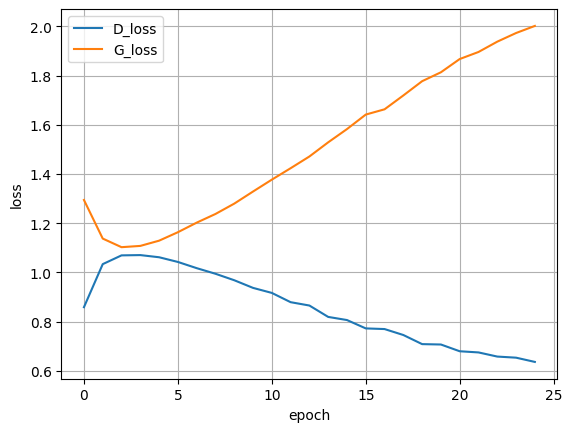

In [10]:
with open(os.path.join(log_dir, 'history.pkl'), 'rb') as f:
    history = pickle.load(f)
D_loss, G_loss = history['D_loss'], history['G_loss']
plt.plot(D_loss, label='D_loss')
plt.plot(G_loss, label='G_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid()

徐々にきれいなMNISTを生成するようになっているのがわかるだろう

--------------------
logs/epoch_005.png


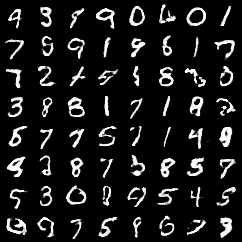

--------------------
logs/epoch_010.png


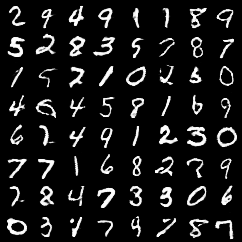

--------------------
logs/epoch_015.png


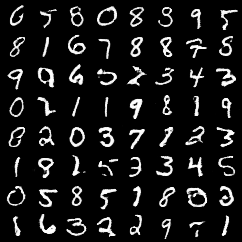

--------------------
logs/epoch_020.png


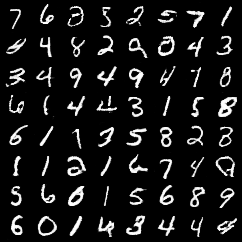

--------------------
logs/epoch_025.png


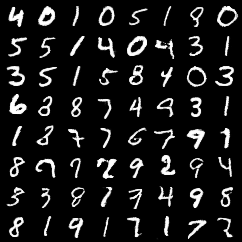

In [11]:
from IPython.display import Image, display_png
for i in list([5, 10, 15, 20, 25]):
    fname = 'logs/epoch_{:03}.png'.format(i)
    print(20*'-')
    print(fname)
    display_png(Image(fname))

余力がある人は、さらに計算パワーが必要なCelebAを試してみると良い

## FIDを実際に計算する

「GANの評価指標」の節で述べたFIDを、ここで学習したGeneratorに対して実際に計算する
- ロス曲線だけでは「画像が良くなっているか」は判断できなかった
- 保存しておいたGenerator（`logs/G_005.pth` など）を読み込み、エポックごとのFIDを求める

FIDは、実画像の特徴量と生成画像の特徴量を、それぞれ1つの多変量ガウス分布で近似し、その2つのガウス分布の間のフレシェ距離（Fréchet distance）を求めたものである
- 実画像側の平均と共分散を $\mu_r, \Sigma_r$、生成画像側を $\mu_g, \Sigma_g$ とすると次の式となる
  - 「GANの評価指標」の節の式と同じものであり、そこでの $\mu_X, \Sigma_X$ が $\mu_r, \Sigma_r$（実画像、real）、$\mu_Y, \Sigma_Y$ が $\mu_g, \Sigma_g$（生成画像、generated）に対応する

$$
\mathrm{FID} = \|\mu_r-\mu_g\|_2^2+\mathrm{Tr}\left(\Sigma_r+\Sigma_g-2\,(\Sigma_r\Sigma_g)^{1/2}\right)
$$

- 最後の項は行列の積そのものではなく、**行列の平方根**（2乗すると元の行列になる行列）である
- 1次元の場合は $(\mu_r-\mu_g)^2+(\sigma_r-\sigma_g)^2$ となり、「平均のずれ」と「広がりのずれ」をそれぞれ2乗して足したものと読める

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-pipeline.png" width=700>

上の図は計算の流れである
- 実画像と生成画像を同じ特徴抽出器に通し、それぞれの特徴量の平均と共分散を求め、最後にその2組からフレシェ距離を計算する
- 画像そのものを直接比べる箇所は無く、比べるのは特徴量の統計量だけである

### フレシェ距離の関数を作る

まず特徴抽出器とは切り離し、平均と共分散を受け取ってフレシェ距離を返す関数を作る
- 行列の平方根は `scipy.linalg.sqrtm` で求まるが、$\Sigma_r\Sigma_g$ は対称行列ではないため、次元が大きいと遅く、誤差で複素数が混ざることがある
- そこで $\mathrm{Tr}\,(\Sigma_r\Sigma_g)^{1/2}=\mathrm{Tr}\,(\Sigma_r^{1/2}\Sigma_g\Sigma_r^{1/2})^{1/2}$ という関係を使う
  - 右辺の括弧の中は対称な半正定値行列になるため、対称行列用の固有値分解（`eigh`）だけで計算でき、速く安定する
- 2次元のガウス分布で、答えが手計算できる場合と比べて確かめる

In [12]:
# 2つのガウス分布のフレシェ距離を平均と共分散から計算し、2次元の例で確かめる
import scipy.linalg
import torch.nn.functional as F

def frechet_distance(mu1, sigma1, mu2, sigma2):
  mu1, mu2 = np.asarray(mu1, dtype=np.float64), np.asarray(mu2, dtype=np.float64)
  sigma1, sigma2 = np.asarray(sigma1, dtype=np.float64), np.asarray(sigma2, dtype=np.float64)
  # sigma1の平方根（対称行列なので固有値の平方根をとれば求まる）
  w, v = np.linalg.eigh(sigma1)
  root1 = (v * np.sqrt(np.clip(w, 0, None))) @ v.T
  # root1 sigma2 root1 の固有値は sigma1 sigma2 の固有値と一致する
  eig = np.linalg.eigvalsh(root1 @ sigma2 @ root1)
  tr_sqrt = np.sqrt(np.clip(eig, 0, None)).sum()
  diff = mu1 - mu2
  return float(diff @ diff + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_sqrt)

def fid_from_features(feat1, feat2):
  # 特徴量（サンプル数 x 次元）から平均と共分散を推定してフレシェ距離を求める
  return frechet_distance(feat1.mean(axis=0), np.cov(feat1, rowvar=False),
                          feat2.mean(axis=0), np.cov(feat2, rowvar=False))

I2 = np.eye(2)
S_corr = np.array([[1.0, 0.8], [0.8, 1.0]])
print('same distribution      : %.4f (expected 0)' % frechet_distance([0, 0], I2, [0, 0], I2))
print('mean shifted by (3, 0) : %.4f (expected 3^2 = 9)' % frechet_distance([0, 0], I2, [3, 0], I2))
print('std 1 vs std 2         : %.4f (expected 2 x (1-2)^2 = 2)' % frechet_distance([0, 0], I2, [0, 0], 4 * I2))
print('uncorrelated vs corr.  : %.4f' % frechet_distance([0, 0], I2, [0, 0], S_corr))

# scipyの行列平方根を使って式どおりに計算した値と一致することを確認
ref = np.trace(I2 + S_corr - 2 * scipy.linalg.sqrtm(I2 @ S_corr)).real
assert abs(ref - frechet_distance([0, 0], I2, [0, 0], S_corr)) < 1e-8

# 同じ分布から取り出した有限個のサンプルどうしでは、0にはならない
rng = np.random.default_rng(0)
for n in [20, 200, 2000, 20000]:
  a = rng.multivariate_normal([0, 0], S_corr, size=n)
  b = rng.multivariate_normal([0, 0], S_corr, size=n)
  print('same distribution, estimated from %5d samples each: %.4f' % (n, fid_from_features(a, b)))

same distribution      : 0.0000 (expected 0)
mean shifted by (3, 0) : 9.0000 (expected 3^2 = 9)
std 1 vs std 2         : 2.0000 (expected 2 x (1-2)^2 = 2)
uncorrelated vs corr.  : 0.4223
same distribution, estimated from    20 samples each: 0.9787
same distribution, estimated from   200 samples each: 0.0687
same distribution, estimated from  2000 samples each: 0.0009
same distribution, estimated from 20000 samples each: 0.0001


結果の読み方
- 同じ分布なら0、平均だけを3ずらすと $3^2=9$、標準偏差だけを1から2にすると各次元で $(1-2)^2=1$ ずつ増えて2となり、式から予想した値と一致する
- 平均も各軸の分散も同じで、相関だけが異なる場合も0にはならない
  - 共分散行列全体を比べているため、分布の「形」の違いも距離に含まれる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-gaussian-distance.png" width=700>

上の図は、この3つの場合を、ガウス分布の広がりを表す楕円で描いたものである
- 左は中心が離れている場合、中央は中心が同じで大きさが違う場合、右は中心も各軸方向の広がりも同じで向き（相関）が違う場合
- フレシェ距離は、楕円の中心のずれ（平均の項）と、楕円の大きさや形のずれ（共分散の項）の和になっている

- 同じ分布から取り出したサンプルどうしでも、平均と共分散を有限個のサンプルから推定するため、値は0より少し大きくなる
  - サンプル数が少ないほど大きい
    - この偏りは後でもう一度確かめる

### 特徴抽出器を用意する

画素値のままでは「数字らしさ」の近さを測れないため、FIDは画像を特徴抽出器に通し、その特徴量の分布どうしを比べる

特徴抽出器には2つの考え方がある
- **標準の方法**: ImageNetで学習済みのInception-v3の、最後の全結合層の直前にある2048次元の出力を使う
  - 論文などで報告されるFIDはこの方法による値であり、他の手法の値と比べられるのはこちらだけである
  - ただし、入力を $299\times 299$ のカラー画像に拡大する必要があり、計算が重い
  - 自然画像で学習したモデルであるため、MNISTのような手書き数字にとって良い特徴とは限らない
- **軽量な代替**: 対象のデータセット（ここではMNIST）で学習した小さなCNNの中間特徴を使う
  - 計算が軽く、そのデータセットに合った特徴となる
  - 得られる値は、その特徴抽出器の中でしか意味を持たない
    - Inception-v3によるFIDとは尺度が異なるため、値を比べてはならない

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-extractors.png" width=700>

上の図は2つの方法の対比である
- どちらも「画像を特徴量に変える」役割は同じで、違うのは前処理、特徴抽出器、特徴量の次元である

まず軽量な方法として、MNISTの数字分類を行う小さなCNNを1エポックだけ学習させ、分類層の直前の64次元を特徴量として使う

In [13]:
# MNISTの分類を行う小さなCNNを学習し、分類層の直前の64次元を特徴量として取り出せるようにする
torch.manual_seed(0)

class FeatNet(nn.Module):
  def __init__(self):
    super(FeatNet, self).__init__()
    self.body = nn.Sequential(
      nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
      nn.Flatten(),
      nn.Linear(64 * 7 * 7, 64), nn.ReLU(),
    )
    self.head = nn.Linear(64, 10)
  def features(self, x):
    return self.body(x)
  def forward(self, x):
    return self.head(self.body(x))

feat_net = FeatNet().to(device)
feat_optimizer = optim.Adam(feat_net.parameters(), lr=1e-3)
n_correct, n_seen = 0, 0
for images, labels in DataLoader(dataset, batch_size=128, shuffle=True):
  images, labels = images.to(device), labels.to(device)
  logits = feat_net(images)
  loss = F.cross_entropy(logits, labels)
  feat_optimizer.zero_grad()
  loss.backward()
  feat_optimizer.step()
  n_correct += (logits.argmax(dim=1) == labels).sum().item()
  n_seen += len(labels)
feat_net.eval()
print('train accuracy during the epoch: %.4f' % (n_correct / n_seen))

@torch.no_grad()
def extract(images, feat_fn, bs=250):
  # 画像（N, 1, 28, 28、値は0〜1）をbs枚ずつ特徴抽出器に通し、特徴量をNumPy配列で返す
  out = [feat_fn(images[i:i + bs].to(device)).double().cpu() for i in range(0, len(images), bs)]
  return torch.cat(out).numpy()

@torch.no_grad()
def sample_fake(G_eval, n, bs=500):
  # 学習時と同じ一様乱数のzからn枚の画像を生成する
  G_eval.eval()
  return torch.cat([G_eval(torch.rand((bs, z_dim), device=device)).cpu() for _ in range(n // bs)])

def load_G(epoch):
  # 保存済みのGeneratorを読み込む（epoch=0は学習前の初期状態）
  G_eval = Generator().to(device)
  if epoch > 0:
    G_eval.load_state_dict(torch.load(os.path.join(log_dir, 'G_%03d.pth' % epoch), map_location=device))
  return G_eval

# 実画像をテンソルとして取り出しておく（ToTensorと同じく0〜1に正規化）
real_all = dataset.data.float().div(255).unsqueeze(1)
print(real_all.shape)

train accuracy during the epoch: 0.9267
torch.Size([60000, 1, 28, 28])


### 学習の進行とFID

学習ループが5エポックごとに保存したGeneratorを順に読み込み、それぞれ1万枚の画像を生成してFIDを求める
- 比較相手は実画像の先頭1万枚
- エポック0として、学習前（初期化直後）のGeneratorも加える
- 基準として、実画像どうし（重複しない1万枚ずつ）のFIDも求める
  - これがこの条件で到達しうる下限の目安となる
- 保存は5エポックごとであり、最初の5エポックの間の変化は見えない
  - そこで、新しいGeneratorとDiscriminatorを用意し、400イテレーション（1エポック弱）だけ学習させながら、50イテレーションごとにFIDを求める
  - 既存の `train()` は変更せず、小さなDataLoaderを渡して繰り返し呼び出す
    - 先に学習した `G` と `D` には影響しない

real vs real : FID(small CNN) = 0.890
epoch  0     : FID(small CNN) = 1028.480
epoch  5     : FID(small CNN) = 4.225
epoch 10     : FID(small CNN) = 2.791
epoch 15     : FID(small CNN) = 4.508
epoch 20     : FID(small CNN) = 3.996
epoch 25     : FID(small CNN) = 3.002
iteration  50: FID(small CNN) = 989.422
iteration 100: FID(small CNN) = 941.962
iteration 150: FID(small CNN) = 908.784
iteration 200: FID(small CNN) = 742.072
iteration 250: FID(small CNN) = 597.693
iteration 300: FID(small CNN) = 405.557
iteration 350: FID(small CNN) = 214.044
iteration 400: FID(small CNN) = 109.680


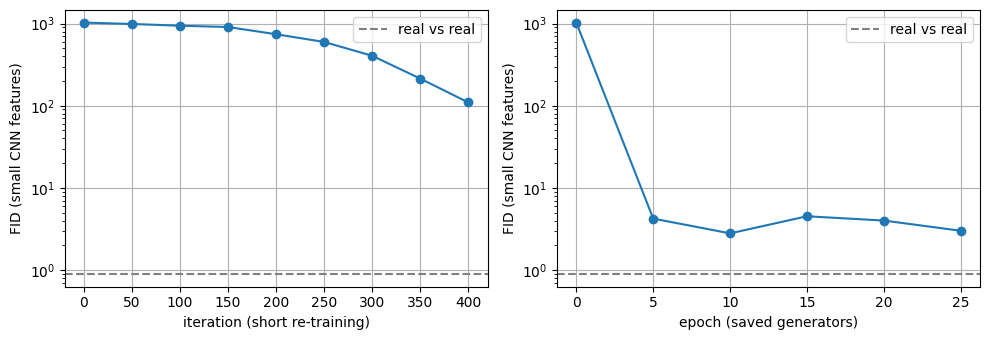

In [14]:
# 保存済みのGeneratorと、短い再学習の途中のGeneratorについて、小さなCNNの特徴量でFIDを計算する
from torch.utils.data import Subset
torch.manual_seed(0)
n_fid = 10000
epochs_fid = [0, 5, 10, 15, 20, 25]
real_feat = extract(real_all[:n_fid], feat_net.features)
real_feat_b = extract(real_all[n_fid:2 * n_fid], feat_net.features)
fid_floor = fid_from_features(real_feat, real_feat_b)
print('real vs real : FID(small CNN) = %.3f' % fid_floor)

def fid_small_cnn(images):
  return fid_from_features(real_feat, extract(images, feat_net.features))

# (a) 学習ループが保存したGenerator
fake_images = {}
fid_small = []
for ep in epochs_fid:
  fake_images[ep] = sample_fake(load_G(ep), n_fid)
  fid_small.append(fid_small_cnn(fake_images[ep]))
  print('epoch %2d     : FID(small CNN) = %.3f' % (ep, fid_small[-1]))

# (b) 最初の1エポック弱を細かく見るための短い再学習
# 既存のtrain()は変更せず、6400枚（50イテレーション分）だけのDataLoaderを渡して繰り返し呼び出す
G2, D2 = Generator().to(device), Discriminator().to(device)
G2_optimizer = optim.Adam(G2.parameters(), lr=lr, betas=(0.5, 0.999))
D2_optimizer = optim.Adam(D2.parameters(), lr=lr, betas=(0.5, 0.999))
chunk = 50 * batch_size
iters_fid, fid_early = [0], [fid_small_cnn(sample_fake(G2, n_fid))]
for k in range(8):
  loader_k = DataLoader(Subset(dataset, range(k * chunk, (k + 1) * chunk)), batch_size=batch_size, shuffle=True)
  train(D2, G2, criterion, D2_optimizer, G2_optimizer, loader_k)
  iters_fid.append((k + 1) * 50)
  fid_early.append(fid_small_cnn(sample_fake(G2, n_fid)))
  print('iteration %3d: FID(small CNN) = %.3f' % (iters_fid[-1], fid_early[-1]))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(iters_fid, fid_early, marker='o')
ax[0].set_xlabel('iteration (short re-training)')
ax[1].plot(epochs_fid, fid_small, marker='o')
ax[1].set_xlabel('epoch (saved generators)')
for a in ax:
  a.axhline(fid_floor, color='gray', linestyle='--', label='real vs real')
  a.set_yscale('log')
  a.set_ylabel('FID (small CNN features)')
  a.legend()
  a.grid()
plt.tight_layout()
plt.show()

結果の読み方
- 左の図（短い再学習）では、学習前に約1000であったFIDが、400イテレーションで約100まで下がり続ける
  - 生成画像が数字らしくなっていく過程を、1つの数の減少として捉えられている
- 右の図（保存済みのGenerator）では、5エポックまでに1桁の値まで下がり、その後はほぼ横ばいとなる
  - 手元の実行例では10エポックが最小（約3）で、25エポックは約4であった
  - 学習が進めば生成画像は実画像に近づき、FIDは下がり続けると予想されるので、これは予想と合わない
  - 乱数シードを変えて画像を生成し直すと値は0.2〜0.3程度ばらつくが、特徴抽出器を学習し直しても10エポックが最小となる傾向は変わらなかった（執筆時に3通りで確認）
    - したがって偶然のばらつきではなく、何か原因がある
  - 原因は、Inception-v3による結果を見た後で、「2つの特徴抽出器で後半の評価が食い違う理由を調べる」で調べる
- 「結果の表示」で、ロス曲線からは学習の良否を判断しにくいと述べたが、FIDを用いれば「5エポックまでに大きく改善し、その後の変化は小さい」と数値で述べられる
- 実画像どうしでも0にはならない（破線）
  - Generatorの値はこの線に届いておらず、実画像の分布との差がまだ残っている
- 値は実行のたびに多少変わる

### Inception-v3による標準的なFID

次に、標準の特徴抽出器であるInception-v3で同じ計算を行う
- `torchvision` が配布するImageNet学習済みの重み（約100MB）をダウンロードする
- 最後の全結合層を恒等写像に置き換え、2048次元の出力を取り出す
- MNISTは $28\times 28$ の1チャネルであるため、$299\times 299$ に拡大し、同じ画像を3チャネルに複製し、ImageNetの平均と標準偏差で正規化してから入力する
- 特徴量が2048次元であるため、共分散行列を推定するにはそれより十分多いサンプルが必要である
  - ここでは計算時間との兼ね合いで5000枚とする

なお、論文で報告されるFIDは、FIDの原論文の実装が用いたInception-v3の重みと前処理で計算されている
- `torchvision` の重みはそれとは別に学習されたものであるため、ここで得る値は「標準と同じ方式による値」であり、論文の数値と厳密に一致させるには、同じ重みと前処理を再現した専用の実装（`pytorch-fid` や `torchmetrics` など）を使う必要がある

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 179MB/s] 


feature shape: (5000, 2048)
real vs real : FID(Inception-v3) = 3.48
epoch  0     : FID(Inception-v3) = 345.77
epoch  5     : FID(Inception-v3) = 23.80
epoch 10     : FID(Inception-v3) = 13.55
epoch 15     : FID(Inception-v3) = 10.40
epoch 20     : FID(Inception-v3) = 10.90
epoch 25     : FID(Inception-v3) = 8.36


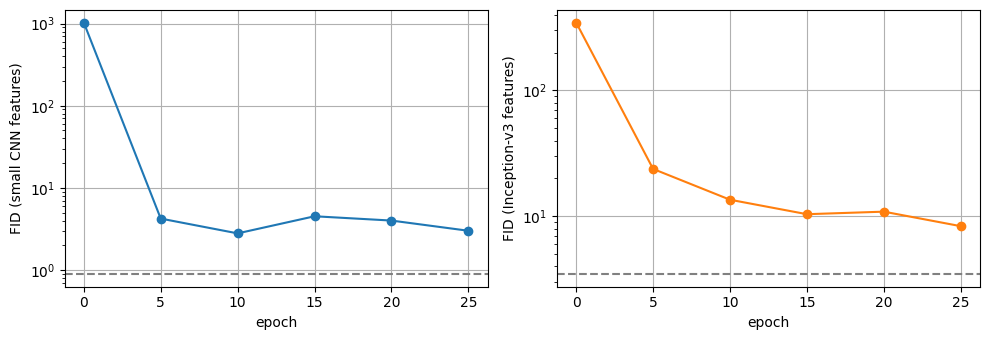

In [15]:
# ImageNet学習済みのInception-v3を特徴抽出器として、同じGeneratorのFIDを計算する（T4で数分）
from torchvision.models import inception_v3, Inception_V3_Weights

inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
inception.fc = nn.Identity()  # 分類層を外し、2048次元の特徴量をそのまま出力させる
inception = inception.to(device).eval()
imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def inception_features(x):
  # 28x28の1チャネル画像を、299x299の3チャネル画像に変換してInception-v3に通す
  x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
  x = (x.repeat(1, 3, 1, 1) - imagenet_mean) / imagenet_std
  return inception(x)

n_inc = 5000
real_feat_inc = extract(real_all[:n_inc], inception_features)
fid_floor_inc = fid_from_features(real_feat_inc, extract(real_all[n_fid:n_fid + n_inc], inception_features))
print('feature shape:', real_feat_inc.shape)
print('real vs real : FID(Inception-v3) = %.2f' % fid_floor_inc)
fid_inc = []
for ep in epochs_fid:
  fid_inc.append(fid_from_features(real_feat_inc, extract(fake_images[ep][:n_inc], inception_features)))
  print('epoch %2d     : FID(Inception-v3) = %.2f' % (ep, fid_inc[-1]))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(epochs_fid, fid_small, marker='o')
ax[0].axhline(fid_floor, color='gray', linestyle='--')
ax[0].set_ylabel('FID (small CNN features)')
ax[1].plot(epochs_fid, fid_inc, marker='o', color='C1')
ax[1].axhline(fid_floor_inc, color='gray', linestyle='--')
ax[1].set_ylabel('FID (Inception-v3 features)')
for a in ax:
  a.set_yscale('log')
  a.set_xlabel('epoch')
  a.grid()
plt.tight_layout()
plt.show()

結果の読み方
- 学習前が最も大きく、学習が進むと小さくなるという傾向は、小さなCNNの場合と同じである
- 値の大きさは全く異なる
  - 尺度が違うため、2つの方法の値を直接比べることはできない
- 手元の実行例では、Inception-v3によるFIDは5エポックの約24から25エポックの約8まで下がり続けた
  - 小さなCNNでは10エポック以降が横ばいであったので、後半の評価が2つの方法で食い違っている
  - 特徴抽出器が変われば、画像のどの違いに敏感であるかが変わり、モデルの順位も変わりうる
  - 具体的に何の違いが効いているのかは、次の重みでも同じ傾向になることを確かめた後で調べる
- 実画像どうしでも約3.5となる
  - 2048次元の共分散行列を5000枚から推定していることによる偏りである
- したがって、FIDを報告するときは、特徴抽出器（重み）、サンプル数、前処理を必ず併記する

### 論文の値と比べられるFIDを計算する

論文で報告されるFIDと同じ物差しにするには、FIDの原論文の実装が使ったInception-v3の重みを使う必要がある
- この重みはTensorFlow用に公開されたもので、`torchvision` の重みとは別に学習されている
- `pytorch-fid` は、この重みをPyTorch用に変換して配布し、前処理も原実装に合わせたパッケージである
  - 通常は `python -m pytorch_fid 実画像のフォルダ 生成画像のフォルダ` のように、画像ファイルを保存したフォルダどうしを比べる形で使う
  - ここでは、その中の特徴抽出器 `InceptionV3` だけを取り出し、フレシェ距離は自作の `frechet_distance` で計算する
- 画像は直前のセルと同じもの（各5000枚）を使うので、値の違いは重みと前処理の違いだけによる

In [16]:
!pip install -q pytorch-fid

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 136MB/s]


               torchvision weights   FID weights (pytorch-fid)
real vs real :         3.48                 3.25
epoch  0     :       345.77               377.27
epoch  5     :        23.80                17.27
epoch 10     :        13.55                10.57
epoch 15     :        10.40                 8.91
epoch 20     :        10.90                 8.58
epoch 25     :         8.36                 7.98


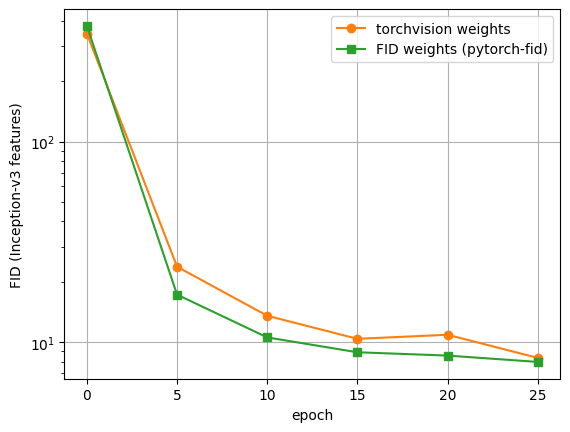

In [17]:
# FID用に配布されているInception-v3の重みで特徴量を取り出し、torchvision版のFIDと比べる（T4で数分）
from pytorch_fid.inception import InceptionV3

fid_net = InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[2048]]).to(device).eval()

def fid_inception_features(x):
  # 0〜1の画像を3チャネルに複製して渡す（299x299への拡大と-1〜1への正規化はモデルの内部で行われる）
  return fid_net(x.repeat(1, 3, 1, 1))[0].flatten(1)

real_feat_std = extract(real_all[:n_inc], fid_inception_features)
real_feat_std_b = extract(real_all[n_fid:n_fid + n_inc], fid_inception_features)
fid_floor_std = fid_from_features(real_feat_std, real_feat_std_b)
print('               torchvision weights   FID weights (pytorch-fid)')
print('real vs real : %12.2f %20.2f' % (fid_floor_inc, fid_floor_std))
fake_feat_std, fid_std = {}, []
for i, ep in enumerate(epochs_fid):
  fake_feat_std[ep] = extract(fake_images[ep][:n_inc], fid_inception_features)
  fid_std.append(fid_from_features(real_feat_std, fake_feat_std[ep]))
  print('epoch %2d     : %12.2f %20.2f' % (ep, fid_inc[i], fid_std[-1]))

plt.plot(epochs_fid, fid_inc, marker='o', color='C1', label='torchvision weights')
plt.plot(epochs_fid, fid_std, marker='s', color='C2', label='FID weights (pytorch-fid)')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('FID (Inception-v3 features)')
plt.legend()
plt.grid()
plt.show()

結果の読み方（数値は手元の実行例）
- 同じ画像に対して、2つの重みで値が異なる
  - 5エポックでは約24と約16、25エポックでは約8.3と約7.8であった
  - 「Inception-v3によるFID」と書かれていても、重みが違えば別の物差しであり、値を並べて比べることはできない
- エポックの順位は2つの重みで一致している
  - 自分の実験の中でモデルを比べるだけであれば、どちらを使っても結論は変わりにくい
- 論文の値と比べるには、重みを合わせるだけでは足りない
  - サンプル数: 論文では生成画像5万枚と、学習データ全体を使うことが多い
    - ここでは5000枚ずつであり、実画像どうしでも約3となる偏りが残っている
  - 前処理: 画像の保存形式（PNGかJPEGか）、リサイズの実装まで合わせる必要がある
  - 比較相手: 実画像として学習データとテストデータのどちらを使うか
- MNISTは白黒の手書き数字であり、Inception-v3が学習した自然画像とは大きく異なる
  - ここでの値は計算手順の確認と考え、数字らしさの評価としては小さなCNNの結果と併せて読むのがよい

### FIDを読むときの注意

FIDは便利であるが、計算の条件によって値が変わる

次の3点を実際に確かめる
- **サンプル数**: 同じGeneratorでも、評価に使う枚数が少ないとFIDは大きく出る
- **前処理**: 画像の縮小と拡大、補間方法などが異なるだけで、同じ画像でも値が変わる
- **1つの数であること**: 「数字の種類が欠けている（多様性の不足）」と「画像が汚い（品質の不足）」は別の問題であるが、FIDではどちらも同じ1つの数の増加として現れる

計算が軽い小さなCNNの特徴量を用いる

### 2つの特徴抽出器で後半の評価が食い違う理由を調べる

ここまでの結果には、予想と合わない点が1つある
- 学習が進めば生成画像は実画像に近づくはずであり、FIDはどの特徴抽出器で測っても下がり続けると予想される
- Inception-v3によるFIDは予想どおり25エポックまで下がり続けた
- 小さなCNNによるFIDは10エポックで最小となり、その後は横ばいからやや上昇した

食い違いの原因を探るため、FIDを式の2つの部分に分けて見る
- **平均の項** $\|\mu_r-\mu_g\|_2^2$: 特徴量の分布の中心がどれだけずれているか
- **共分散の項** $\mathrm{Tr}(\Sigma_r+\Sigma_g-2(\Sigma_r\Sigma_g)^{1/2})$: 分布の広がりや形がどれだけ違うか

あわせて、特徴抽出器を通さない単純な量として、画像の画素値の平均（線の太さや濃さ、いわば「インクの量」）も実画像と比べる

real images: mean pixel value = 0.1311
           small CNN             Inception-v3 (FID weights)   mean pixel
           mean term  cov term   mean term  cov term          value
epoch  5 :    1.467     2.758       5.903    11.368          0.1329
epoch 10 :    0.599     2.192       2.575     7.995          0.1291
epoch 15 :    2.219     2.288       2.010     6.904          0.1259
epoch 20 :    1.780     2.216       1.743     6.838          0.1229
epoch 25 :    1.053     1.949       1.498     6.481          0.1284


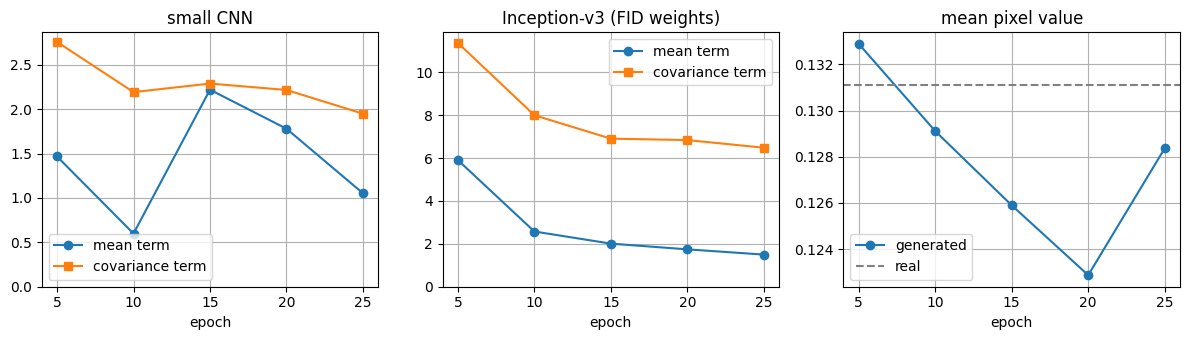

FID (small CNN)    as generated   mean pixel value matched to real
epoch  5 :            4.225            4.493
epoch 10 :            2.791            2.519
epoch 15 :            4.508            4.296
epoch 20 :            3.996            2.693
epoch 25 :            3.002            2.087
real vs real x 0.95 : 6.259   (real vs real : 0.890)


In [18]:
# FIDを「平均の項」と「共分散の項」に分け、エポックごとにどちらが変化しているかを調べる
def fid_terms(feat1, feat2):
  mean_term = float(((feat1.mean(axis=0) - feat2.mean(axis=0)) ** 2).sum())
  return mean_term, fid_from_features(feat1, feat2) - mean_term

ink_real = real_all[:n_fid].mean().item()
print('real images: mean pixel value = %.4f' % ink_real)
print('           small CNN             Inception-v3 (FID weights)   mean pixel')
print('           mean term  cov term   mean term  cov term          value')
terms = []
for ep in epochs_fid[1:]:
  m1, c1 = fid_terms(real_feat, extract(fake_images[ep], feat_net.features))
  m2, c2 = fid_terms(real_feat_std[:n_inc], fake_feat_std[ep])
  terms.append((m1, c1, m2, c2, fake_images[ep].mean().item()))
  print('epoch %2d : %8.3f %9.3f %11.3f %9.3f %15.4f' % ((ep,) + terms[-1]))
terms = np.array(terms)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
for a, j, title in [(ax[0], 0, 'small CNN'), (ax[1], 2, 'Inception-v3 (FID weights)')]:
  a.plot(epochs_fid[1:], terms[:, j], marker='o', label='mean term')
  a.plot(epochs_fid[1:], terms[:, j + 1], marker='s', label='covariance term')
  a.set_title(title)
  a.set_ylim(bottom=0)
ax[2].plot(epochs_fid[1:], terms[:, 4], marker='o', label='generated')
ax[2].axhline(ink_real, color='gray', linestyle='--', label='real')
ax[2].set_title('mean pixel value')
for a in ax:
  a.set_xlabel('epoch')
  a.legend()
  a.grid()
plt.tight_layout()
plt.show()

# 画素値の平均の違いが原因かを確かめる: 生成画像の画素値を定数倍し、平均を実画像に合わせてからFIDを計算し直す
print('FID (small CNN)    as generated   mean pixel value matched to real')
fid_matched = []
for ep in epochs_fid[1:]:
  matched = (fake_images[ep] * (ink_real / fake_images[ep].mean())).clamp(0, 1)
  fid_matched.append(fid_small_cnn(matched))
  print('epoch %2d : %16.3f %16.3f' % (ep, fid_small_cnn(fake_images[ep]), fid_matched[-1]))
# 参考: 実画像の別の1万枚を5%だけ薄くした場合のFID（何もしなければ fid_floor）
print('real vs real x 0.95 : %.3f   (real vs real : %.3f)' % (fid_small_cnn(real_all[n_fid:2 * n_fid] * 0.95), fid_floor))

結果の読み方（数値は手元の実行例）
- 小さなCNN
  - 共分散の項は5エポックの3.6から10エポックの2.3へ下がり、その後は2.2〜2.5で横ばいである
  - 平均の項は20エポックまで1.0〜1.2で、25エポックに1.6へ増えた
  - 後半にFIDが下がらないのは、分布の形の改善が止まり、分布の中心が少しずつずれていくためである
- Inception-v3
  - 平均の項も共分散の項も、25エポックまで下がり続ける
- 画素値の平均
  - 実画像は0.131である
  - 生成画像は10エポックまで0.130でほぼ同じだが、15エポック以降は0.124〜0.125と、約5%小さい
  - 15エポック以降のGeneratorは、実画像より少し薄い（または線の細い）数字を出している
- 画素値の平均を実画像に合わせて測り直した場合
  - 小さなCNNのFIDは、10エポックの3.4に対し、15〜25エポックは2.6〜3.2となり、10エポックが最小ではなくなる
  - 実画像を5%薄くしただけで、小さなCNNのFIDは0.9から6.4に増える
    - この特徴抽出器は、画像の濃さの違いに非常に敏感である

以上から、食い違いは次のように説明できる
- 小さなCNNのFIDが後半に下がらなかった主な原因は、Generatorの出力が15エポック以降わずかに薄くなったことである
  - 濃さを揃えれば、小さなCNNで測っても後半のGeneratorの方が実画像に近い
- これは測定の誤りではない
  - 濃さの違いも実画像との実際の違いであり、小さなCNNのFIDはそれを正しく拾っている
  - ただし「数字の形が良くなったか」という関心とは別の違いが、1つの数に混ざっていたことになる
- Inception-v3のFIDが下がり続けたのは、濃さの違いよりも形や輪郭の改善が値に大きく効いたためと考えられる
  - ただし、Inception-v3が濃さの違いにどの程度敏感かはここでは測っていないので、断定はできない
- Generatorの出力がなぜ薄くなったのかも、この実験からは分からない

FIDが予想と違う動きをしたときは、このように、平均と共分散に分ける、特徴抽出器を通さない単純な量を比べる、原因と思われる違いを取り除いて測り直す、という手順で中身を調べられる

(1) number of samples (epoch 25 vs real / real vs real)
  n =   100 : 63.100 / 40.501
  n =   300 : 16.201 / 17.058
  n =  1000 : 11.402 / 8.072
  n =  3000 : 4.751 / 1.970
  n = 10000 : 3.002 / 0.890
(2) real vs real resized 28->14->28 (nearest ): 56.033
(2) real vs real resized 28->14->28 (bilinear): 201.384
(3) real vs digits 0-4 only (low diversity): 119.399
(3) real vs noisy images    (low quality)  : 95.406


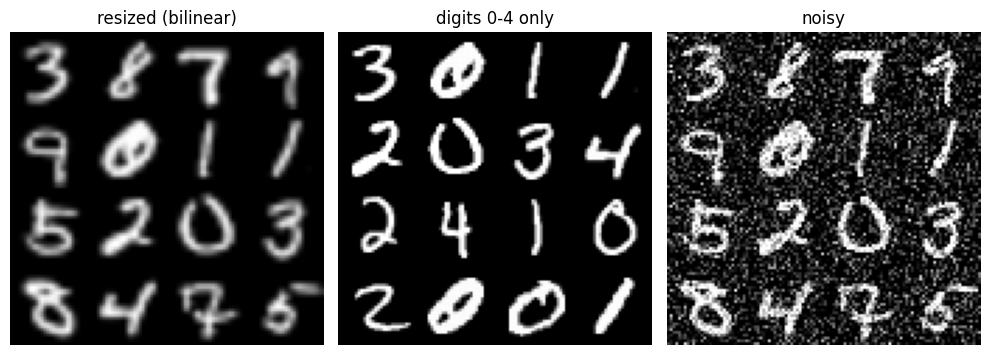

In [19]:
# サンプル数、前処理、多様性と品質の違いがFIDに与える影響を確かめる（小さなCNNの特徴量を使用）
torch.manual_seed(0)
fake_feat = extract(fake_images[25], feat_net.features)

# (1) サンプル数による偏り: 同じ特徴量の先頭n個だけを使う
print('(1) number of samples (epoch 25 vs real / real vs real)')
for n in [100, 300, 1000, 3000, 10000]:
  print('  n = %5d : %.3f / %.3f' % (n, fid_from_features(real_feat[:n], fake_feat[:n]),
                                    fid_from_features(real_feat[:n], real_feat_b[:n])))

# (2) 前処理の違い: 実画像の別の1万枚を、半分に縮小してから元の大きさに戻す
real_b = real_all[n_fid:2 * n_fid]
small = F.interpolate(real_b, size=(14, 14), mode='bilinear', align_corners=False)
for mode in ['nearest', 'bilinear']:
  resized = F.interpolate(small, size=(28, 28), mode=mode)
  print('(2) real vs real resized 28->14->28 (%-8s): %.3f' % (mode, fid_from_features(real_feat, extract(resized, feat_net.features))))

# (3) 多様性の不足と品質の不足: どちらも実画像から作る
rest_images, rest_labels = real_all[n_fid:], dataset.targets[n_fid:]
only_0to4 = rest_images[rest_labels < 5][:n_fid]            # 鮮明だが、数字0〜4しか含まない
noisy = (real_b + 0.3 * torch.randn_like(real_b)).clamp(0, 1)  # 全種類の数字を含むが、ノイズが乗っている
fid_div = fid_from_features(real_feat, extract(only_0to4, feat_net.features))
fid_qual = fid_from_features(real_feat, extract(noisy, feat_net.features))
print('(3) real vs digits 0-4 only (low diversity): %.3f' % fid_div)
print('(3) real vs noisy images    (low quality)  : %.3f' % fid_qual)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
for a, (name, imgs) in zip(ax, [('resized (bilinear)', resized), ('digits 0-4 only', only_0to4), ('noisy', noisy)]):
  grid = imgs[:16].view(4, 4, 28, 28).permute(0, 2, 1, 3).reshape(112, 112)
  a.imshow(grid, cmap='gray')
  a.set_title(name)
  a.axis('off')
plt.tight_layout()
plt.show()

結果の読み方（数値は手元の実行例）
- サンプル数
  - 100枚では、実画像どうしでも約40となり、25エポックのGeneratorの値（約46）とほとんど区別できない
  - 1000枚での実画像どうしの値（約8）は、1万枚でのGeneratorの値（約4）より大きい
    - 枚数が異なるFIDを比べると、結論を誤る
  - 偏りは常に値を大きくする方向に働く
    - 論文では5万枚の生成画像を用いることが多い
- 前処理
  - 半分に縮小して元に戻しただけの実画像は、人の目には少しぼけた同じ数字に見えるが、FIDは55〜200となり、Generatorの値（約4）よりはるかに大きい
  - 補間方法を変えるだけで値が数倍変わる
  - 実画像と生成画像には必ず同じ前処理を適用する
    - リサイズの実装（ライブラリ、補間方法、アンチエイリアスの有無）の違いが報告値を変えることは、Inception-v3による標準のFIDでも指摘されている（Parmar et al., 2022）
- 多様性と品質
  - 「鮮明だが数字0〜4しかない画像」は約120、「全種類の数字があるがノイズの乗った画像」は約95となり、どちらも同程度に大きい
  - 数値だけを見ても、多様性が足りないのか、品質が低いのかは区別できない
  - 生成画像を実際に目で見ること、品質と多様性を分けて測る指標（Precision and Recall、Kynkäänniemi et al., 2019）を併用することが必要である
- このほか、FIDは特徴量の分布をガウス分布とみなし、平均と共分散だけを比べている
  - それ以外の違いは値に現れない

### FID以外の指標

FIDの弱点を補う指標を3つ取り上げ、どれも自作して値を確かめる

**Inception Score（IS）**
- 実画像を使わず、分類器が生成画像に対して出すクラス確率 $p(y|x)$ だけから計算する
- 「1枚ごとには何のクラスかがはっきりしている（$p(y|x)$ が1つのクラスに集中する）」かつ「全体ではさまざまなクラスが出ている（平均 $p(y)$ が平らである）」ほど大きくなる

$$
\mathrm{IS}=\exp\left(\mathbb{E}_{x\sim p_g}\left[D_{KL}\left(p(y|x)\,\|\,p(y)\right)\right]\right)
$$

- 値は1以上、クラス数以下で、大きいほどよい
- 標準ではInception-v3のImageNet 1000クラスの出力を使う
  - MNISTの数字はImageNetのクラスに無いため、ここでは特徴抽出に使った小さなCNNの10クラスの出力で代用する
  - したがって最大値は10であり、論文のISとは比べられない

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-inception-score.png" width=700>

上の図は、ISが大きくなる場合と小さくなる場合である
- 上段が1枚ごとのクラス確率、下段が全体の平均であり、上段が尖り、下段が平らなとき（左）だけISが大きくなる
- 1種類の数字しか出さない場合（中央）も、何の数字か分からない画像の場合（右）も、上段と下段の形が同じになり、ISは1に近づく

**KID（Kernel Inception Distance）**
- FIDと同じ特徴量を使うが、ガウス分布を仮定しない
- 2組のサンプルが同じ分布から来たかを、カーネル関数 $k$ を用いて測るMMD（Maximum Mean Discrepancy）の2乗を使う
  - カーネルは3次の多項式 $k(x,y)=(x^\top y/d+1)^3$（$d$ は特徴量の次元）
- 実画像の特徴量を $x_1,\dots,x_n$、生成画像の特徴量を $y_1,\dots,y_m$ とする

$$
\mathrm{KID}=\frac{1}{n(n-1)}\sum_{i\neq j}k(x_i,x_j)+\frac{1}{m(m-1)}\sum_{i\neq j}k(y_i,y_j)-\frac{2}{nm}\sum_{i,j}k(x_i,y_j)
$$

- 同じ組の中の類似度が、異なる組の間の類似度より高いほど大きくなり、小さいほどよい
- この式は不偏推定量であり、サンプル数が少なくても値が系統的に大きくなることがない
  - 同じ分布どうしでは0のまわりにばらつき、負の値にもなる

**適合率（Precision）と再現率（Recall）**
- 特徴量の空間で、実画像の各点を中心に「$k$ 番目に近い実画像までの距離」を半径とする球を置き、その球の集まりを「実画像が存在する領域」とみなす
- 適合率: 生成画像のうち、実画像の領域に入るものの割合
  - 生成画像が本物らしいか（品質）を表す
- 再現率: 生成画像の側で同じように領域を作り、実画像のうち、その領域に入るものの割合
  - 実画像の多様さを生成画像が覆えているか（多様性）を表す
- 分類の評価で用いる適合率と再現率と同じ考え方を、分布どうしの比較に持ち込んだものである
- $k=3$ とする

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-precision-recall.png" width=750>

上の図は、2次元の特徴量を例に数え方を示したものである（$k=3$）
- 左: 実画像の点のまわりに球を置き、生成画像がそのどれかに入るかを調べ、入った割合を適合率とする
- 右: 役割を入れ替え、生成画像の点のまわりに球を置き、実画像がそのどれかに入るかを調べ、入った割合を再現率とする
- この例では、生成画像が左側の実画像の集まりの近くにしか無いため、右側の実画像は生成画像の球に入らず、再現率が低くなる

IS, 10 classes evenly and confidently: 10.000 (expected 10)
IS, a single class only              : 1.000 (expected 1)
IS, real MNIST images                : 8.923
               FID      KID   precision  recall     IS
real vs real :   3.25   0.0004    0.773    0.806    8.852
epoch  0     : 377.27   0.4910    0.000    0.000    1.000
epoch  5     :  17.27   0.0120    0.514    0.577    7.638
epoch 10     :  10.57   0.0052    0.598    0.623    7.952
epoch 15     :   8.91   0.0040    0.626    0.659    8.097
epoch 20     :   8.58   0.0034    0.604    0.697    8.057
epoch 25     :   7.98   0.0030    0.628    0.695    8.130
real vs real with n samples
  n =  500 : FID =   19.74   KID =  0.00003
  n = 1000 : FID =   10.95   KID = -0.00011
  n = 2000 : FID =    6.10   KID =  0.00001
  n = 5000 : FID =    2.53   KID =  0.00001


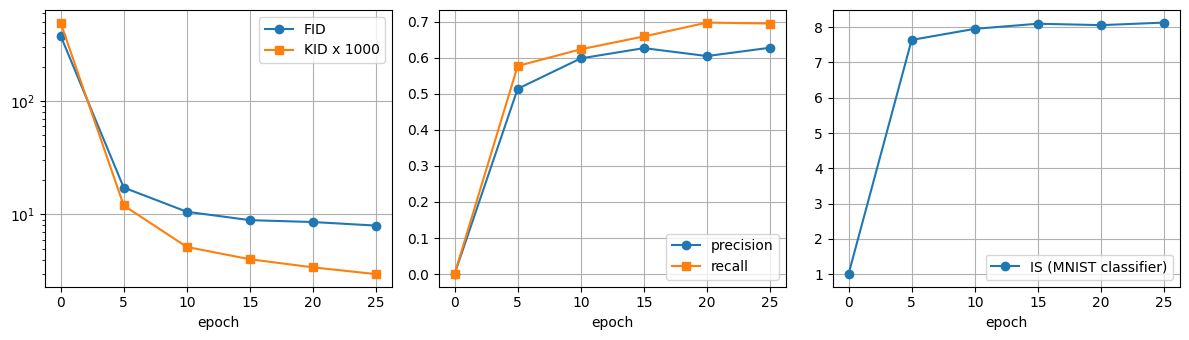

In [20]:
# Inception Score、KID、適合率と再現率を自作し、エポックごとの値を求める
def inception_score(probs):
  # probs: 各画像のクラス確率（枚数 x クラス数）
  p_y = probs.mean(axis=0, keepdims=True)
  kl = (probs * (np.log(probs + 1e-12) - np.log(p_y + 1e-12))).sum(axis=1)
  return float(np.exp(kl.mean()))

def classify(images):
  # 小さなCNNの分類結果（クラス確率）を返す
  return extract(images, lambda x: F.softmax(feat_net(x), dim=1))

def kid(feat1, feat2):
  # 3次の多項式カーネル k(x, y) = (x・y / d + 1)^3 によるMMDの2乗の不偏推定量
  d = feat1.shape[1]
  k11, k22, k12 = (feat1 @ feat1.T / d + 1) ** 3, (feat2 @ feat2.T / d + 1) ** 3, (feat1 @ feat2.T / d + 1) ** 3
  n, m = len(feat1), len(feat2)
  return float((k11.sum() - np.trace(k11)) / (n * (n - 1)) + (k22.sum() - np.trace(k22)) / (m * (m - 1)) - 2 * k12.mean())

@torch.no_grad()
def precision_recall(real_feat, fake_feat, k=3):
  r = torch.as_tensor(real_feat, dtype=torch.float32, device=device)
  g = torch.as_tensor(fake_feat, dtype=torch.float32, device=device)
  def kth_radius(x):
    # 各点から、同じ集合の中でk番目に近い点までの距離（自分自身の距離0を除くためk+1番目をとる）
    return torch.cdist(x, x).kthvalue(k + 1, dim=1).values
  d_gr = torch.cdist(g, r)  # 行が生成画像、列が実画像
  precision = (d_gr <= kth_radius(r)[None, :]).any(dim=1).float().mean().item()   # 実画像の球のどれかに入る生成画像の割合
  recall = (d_gr.T <= kth_radius(g)[None, :]).any(dim=1).float().mean().item()    # 生成画像の球のどれかに入る実画像の割合
  return precision, recall

# 自作関数の確認: 値が分かっている場合
print('IS, 10 classes evenly and confidently: %.3f (expected 10)' % inception_score(np.eye(10)[np.arange(1000) % 10]))
print('IS, a single class only              : %.3f (expected 1)' % inception_score(np.eye(10)[np.zeros(1000, dtype=int)]))
print('IS, real MNIST images                : %.3f' % inception_score(classify(real_all[:n_fid])))

# エポックごとの値（FID、KID、適合率、再現率はFID用のInception-v3特徴量、ISは小さなCNNの分類結果を使用）
print('               FID      KID   precision  recall     IS')
p, r = precision_recall(real_feat_std, real_feat_std_b)
print('real vs real : %6.2f %8.4f %8.3f %8.3f %8.3f' % (fid_floor_std, kid(real_feat_std, real_feat_std_b), p, r, inception_score(classify(real_all[n_fid:2 * n_fid]))))
kid_std, prec_std, rec_std, is_small = [], [], [], []
for i, ep in enumerate(epochs_fid):
  p, r = precision_recall(real_feat_std, fake_feat_std[ep])
  kid_std.append(kid(real_feat_std, fake_feat_std[ep]))
  prec_std.append(p)
  rec_std.append(r)
  is_small.append(inception_score(classify(fake_images[ep])))
  print('epoch %2d     : %6.2f %8.4f %8.3f %8.3f %8.3f' % (ep, fid_std[i], kid_std[-1], p, r, is_small[-1]))

# サンプル数を変えたときのFIDとKID（実画像1万枚を混ぜ、重複しないn枚ずつを取り出して比べる、どちらも本来の値は0）
print('real vs real with n samples')
real_pool = np.concatenate([real_feat_std, real_feat_std_b])[np.random.default_rng(0).permutation(2 * n_inc)]
for n in [500, 1000, 2000, 5000]:
  print('  n = %4d : FID = %7.2f   KID = %8.5f' % (n, fid_from_features(real_pool[:n], real_pool[n:2 * n]), kid(real_pool[:n], real_pool[n:2 * n])))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
ax[0].plot(epochs_fid, fid_std, marker='o', label='FID')
ax[0].plot(epochs_fid, [1000 * v for v in kid_std], marker='s', label='KID x 1000')
ax[0].set_yscale('log')
ax[1].plot(epochs_fid, prec_std, marker='o', label='precision')
ax[1].plot(epochs_fid, rec_std, marker='s', label='recall')
ax[2].plot(epochs_fid, is_small, marker='o', label='IS (MNIST classifier)')
for a in ax:
  a.set_xlabel('epoch')
  a.legend()
  a.grid()
plt.tight_layout()
plt.show()

結果の読み方（数値は手元の実行例）
- 自作関数の確認
  - ISは、10クラスが均等に、かつ確信を持って出る場合に10、1クラスしか出ない場合に1となり、定義どおりである
  - 実画像のISは約8.9で、10にはならない
    - 分類器の出す確率が1つのクラスに完全には集中しないためであり、ISの値は分類器にも依存する
- エポックごとの値
  - KIDはFIDと同じ傾向で下がる
  - 適合率は5エポックの約0.49から25エポックの約0.64へ、再現率は約0.62から約0.71へ上がる
    - 実画像どうしでも適合率0.77、再現率0.81であり、1にはならず、これがこの条件での上限の目安である
    - 学習が進んでも、品質と多様性のどちらにも実画像との差が残っていることが、2つの数に分けて読み取れる
  - ISは5エポックで約7.7、10エポック以降は約8.1で横ばいである
    - FIDが16から7.8へ下がった後半の改善を、ISはほとんど捉えていない
    - 「何の数字かが分かり、10種類が出ている」ことしか見ていないためである
- サンプル数
  - 同じ実画像の集まりから取り出した2組であるから、本来の値はどちらも0である
  - FIDは500枚で約20、5000枚でも約2.5と、枚数が少ないほど大きい
  - KIDはどの枚数でも0のまわりの小さな値（正にも負にもなる）である
  - 画像を多く用意できない場合や、枚数の異なる結果を比べたい場合は、KIDの方が扱いやすい

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-sample-bias.png" width=550>

上の図は、この違いを模式的に描いたものである
- FIDの推定値は、枚数が少ないほど真の値より大きく出て、枚数を増やすと上から真の値に近づく
- KIDの推定値は、枚数が少ないとばらつきは大きくなるが、平均的には真の値からずれない

### 多様性を失った生成器で指標の動きを確かめる

指標の意味を確かめるため、25エポックのGeneratorを元に、性質の分かっている「悪い生成器」を意図的に作る
- **一部の数字しか出さない生成器**: Generatorの出力を小さなCNNで分類し、指定した数字と判定された画像だけを出力として採用する
  - GANの学習で起きるモード崩壊（mode collapse、一部の種類の画像しか生成しなくなる現象）を模したもの
  - 1枚ごとの画像は元のGeneratorの出力そのものであり、品質は変わらない
- **潜在変数 $z$ の範囲を狭めた生成器**: $z$ を一様乱数の中心0.5のまわりの狭い範囲からだけ取り出す
  - 入力の変化が乏しくなり、似た画像ばかりを出すようになる
- **ノイズの乗った生成器**: 全種類の数字を出すが、出力にノイズを加える（品質の低下）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-quality-vs-diversity.png" width=750>

上の図は、特徴量の空間で実画像のある領域と生成画像のある領域がどう重なるかと、適合率・再現率の関係を示す
- 多様性だけが足りない場合は、生成画像が実画像の領域の一部にしか無く、適合率は高いまま再現率が下がる
- 品質だけが足りない場合は、生成画像が実画像の領域の外にはみ出し、適合率が下がる
- 生成画像の領域全体がずれる場合は、両方が下がる
- 以下の実験で、3種類の「悪い生成器」がこのどれに当たるかを確かめる

各5000枚について、FID、適合率、再現率、ISを求める
- 特徴量には計算の軽い小さなCNNを使う

                     FID   precision  recall     IS
all digits           3.66    0.842    0.838    8.189
digits 0-4 only    110.76    0.857    0.459    4.972
digits 0-1 only    418.27    0.860    0.185    2.178
digit 0 only       780.85    0.863    0.075    1.131
z range x 0.50     100.15    0.903    0.381    5.575
z range x 0.20     607.38    0.962    0.002    1.149
z range x 0.05     813.88    1.000    0.000    1.000
noisy output       106.43    0.797    0.074    6.003


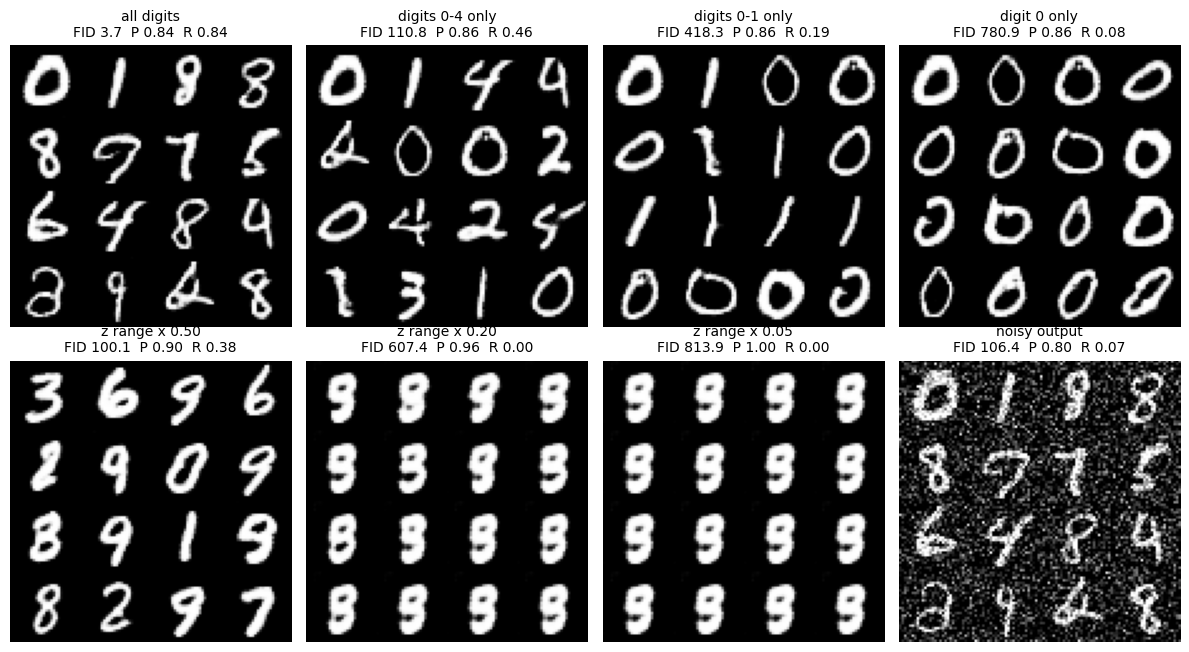

In [21]:
# 意図的に多様性または品質を落とした生成器を作り、FID、適合率、再現率、ISの動きを比べる
torch.manual_seed(0)
n_pr = 5000
G25 = load_G(25)
pool = sample_fake(G25, 60000)                                 # 25エポックのGeneratorの出力を多めに用意
pool_pred = torch.from_numpy(classify(pool).argmax(axis=1))    # 小さなCNNで数字の種類を判定

variants = {'all digits': pool[:n_pr]}
# (a) 一部の数字しか出さない生成器: 指定した数字と判定された画像だけを出力として採用する
variants['digits 0-4 only'] = pool[pool_pred < 5][:n_pr]
variants['digits 0-1 only'] = pool[pool_pred < 2][:n_pr]
variants['digit 0 only'] = pool[pool_pred < 1][:n_pr]
# (b) 潜在変数zの範囲を中心0.5のまわりに狭める: 数字の種類ではなく、書き方の変化が乏しくなる
with torch.no_grad():
  for s in [0.5, 0.2, 0.05]:
    z = 0.5 + s * (torch.rand((n_pr, z_dim), device=device) - 0.5)
    variants['z range x %.2f' % s] = G25(z).cpu()
# (c) 品質の低下: 全種類の数字を出すが、出力にノイズが乗る
variants['noisy output'] = (pool[:n_pr] + 0.3 * torch.randn_like(pool[:n_pr])).clamp(0, 1)

real_feat_pr = real_feat[:n_pr]
print('                     FID   precision  recall     IS')
results = {}
for name, images in variants.items():
  feat = extract(images, feat_net.features)
  p, r = precision_recall(real_feat_pr, feat)
  results[name] = (fid_from_features(real_feat_pr, feat), p, r, inception_score(classify(images)))
  print('%-16s %8.2f %8.3f %8.3f %8.3f' % ((name,) + results[name]))

fig, ax = plt.subplots(2, 4, figsize=(12, 6.6))
for a, (name, images) in zip(ax.flat, variants.items()):
  a.imshow(images[:16].view(4, 4, 28, 28).permute(0, 2, 1, 3).reshape(112, 112), cmap='gray')
  a.set_title('%s\nFID %.1f  P %.2f  R %.2f' % ((name,) + results[name][:3]), fontsize=10)
  a.axis('off')
plt.tight_layout()
plt.show()

結果の読み方（数値は手元の実行例）
- 一部の数字しか出さない生成器
  - 適合率は0.82〜0.85でほとんど変わらず、1枚ごとの画像の質は元のままであることと合っている
  - 再現率は、全種類の0.84から、5種類で0.47、2種類で0.18、1種類で0.08と、出せる数字の種類にほぼ比例して下がる
  - ISは8.1、5.0、2.2、1.1と、出している数字の種類の数に近い値になる
  - FIDは5から113、436、819へと大きくなる
- $z$ の範囲を狭めた生成器
  - 図のとおり、範囲を狭めるほど同じような数字ばかりになる
  - 再現率は0.42から0へ下がる
  - 適合率は高い値になったが、0.2倍以下の範囲では実行ごとに大きく変わる
  - 「無難な画像を1種類だけ出す」生成器が、適合率だけを見ると良い生成器に見えてしまう場合がある
- FIDだけを見た場合
  - 「数字0〜4のみ」（113）、「$z$ の範囲0.5倍」（104）、「ノイズあり」（110）はほぼ同じ値であり、区別できない
  - 適合率と再現率を併せて見ると、前の2つは「品質は保たれているが多様性が足りない」と読み取れる
- ノイズの乗った生成器
  - 人の目には品質の低下であるが、適合率は0.77とあまり下がらず、再現率が0.07まで大きく下がった
  - 「品質が下がれば適合率が下がり、多様性が同じなら再現率は変わらない」という予想とは逆である
- 予想と合わなかったこの2点（ノイズでの再現率の低下、$z$ を狭めたときの適合率のばらつき）は、指標のまとめの後で原因を調べる

### 指標のまとめ

| 指標 | 実画像との比較 | 良い方向 | 分かること | 弱点 |
|---|---|---|---|---|
| FID | する | 小さい | 品質と多様性を合わせた全体の近さ | サンプル数が少ないと大きく出る、原因を区別できない |
| KID | する | 小さい | FIDと同様 | カーネルの選び方に依存する、FIDほど報告例が多くない |
| IS | しない | 大きい | クラスが明確か、クラスが偏っていないか | 実画像に近いかは分からない、クラスの中の多様性を見ない |
| 適合率と再現率 | する | 大きい | 品質と多様性を分けて見られる | 外れ値や特徴抽出器の性質に左右される |

- どの指標も、特徴抽出器（または分類器）が見ている範囲でしか画像を評価していない
- どの指標も、学習データを丸暗記してそのまま出力する生成器を見分けられない
  - 実画像と比べる指標では、丸暗記した生成器が最も良い値になる
- 1つの数値だけで判断せず、複数の指標を併用し、生成画像を必ず目で見て確かめる

### 適合率と再現率が予想と合わない理由を調べる

感覚としては、「適合率＝見た目の品質」「再現率＝数字の種類の多さ」と対応するように思うが、厳密には成り立たない

計算したのは、特徴空間での次の割合である

| 指標 | 数えているもの |
| -- | -- |
|適合率 | 生成画像の点が、実画像の球の集まりに入る割合 |
|再現率 | 実画像の点が、生成画像の球の集まりに入る割合 |

ノイズの場合、「数字の種類が減っていないから再現率は保たれる」という予想が単純すぎた

- ノイズの乗った生成器
  - 予想: 数字の種類は減っていないので再現率は保たれ、画像が汚くなったので適合率が下がる
  - 結果: 適合率はあまり下がらず、再現率が大きく下がった
- $z$ の範囲を極端に狭めた生成器
  - 予想: 同じ画像しか出さないので再現率は0、その1枚が本物らしければ適合率は1、本物らしくなければ0
  - 結果: 再現率は0となったが、適合率は実行のたびに大きく変わる

ここでは、FIDは多様性の不足とノイズによる劣化を、いずれも実画像との分布の違いとして捉えた
- 一方、適合率と再現率の結果は、見た目の品質や数字の種類の多さだけでは説明できない
- これらの指標を解釈するには、特徴空間での領域の重なりを調べる必要がある

そこで、適合率と再現率が実際に何を計算しているのか、特徴量の空間での距離を直接調べる

- 適合率は「生成画像が、実画像の球のどれか1つに入るか」で決まる
  - 球の半径は実画像ごとに異なり、周囲に他の実画像が少ない、まばらな場所にある実画像ほど半径が大きい
- ここでは、次の量を求める
  - 生成画像から最も近い実画像までの距離（中央値）
  - 実画像の球の半径（中央値と上位10%の値）、生成画像の球の半径（中央値）
  - 半径が中央値以下の「小さい球」だけを使って数え直した適合率

(1) noise     precision  (small balls)  recall | distance to nearest real | radius of generated balls
sigma = 0.00 :   0.842       0.401      0.838 |           6.76                     7.74
sigma = 0.05 :   0.865       0.403      0.779 |           6.76                     7.51
sigma = 0.10 :   0.863       0.375      0.648 |           6.83                     7.25
sigma = 0.20 :   0.831       0.209      0.278 |           7.48                     6.72
sigma = 0.30 :   0.776       0.063      0.065 |           8.61                     6.34
sigma = 0.50 :   0.664       0.001      0.003 |          10.38                     5.71
radius of real balls: median 7.49, top 10% 10.60
k =  1, sigma = 0.3 : precision 0.415  recall 0.018
k =  3, sigma = 0.3 : precision 0.776  recall 0.065
k = 10, sigma = 0.3 : precision 0.987  recall 0.210
(2) z range   precision  (small balls)  recall | distance to nearest real | radius of generated balls
all digits    :  0.842       0.401      0.838 |           6.76 

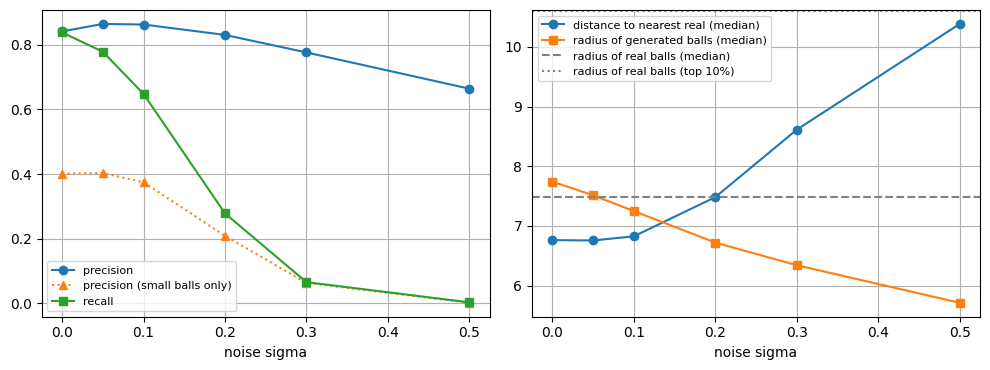

In [22]:
# ノイズ量を段階的に変え、適合率・再現率と、特徴量の空間での距離や球の半径の変化を調べる
@torch.no_grad()
def pr_diagnose(real_feat, fake_feat, k=3):
  r = torch.as_tensor(real_feat, dtype=torch.float32, device=device)
  g = torch.as_tensor(fake_feat, dtype=torch.float32, device=device)
  rad_r = torch.cdist(r, r).kthvalue(k + 1, dim=1).values   # 実画像の球の半径
  rad_g = torch.cdist(g, g).kthvalue(k + 1, dim=1).values   # 生成画像の球の半径
  d = torch.cdist(g, r)
  inside = d <= rad_r[None, :]
  small = rad_r <= rad_r.median()
  return {
    'precision': inside.any(dim=1).float().mean().item(),
    'precision_small': inside[:, small].any(dim=1).float().mean().item(),   # 小さい球だけを使った適合率
    'recall': (d.T <= rad_g[None, :]).any(dim=1).float().mean().item(),
    'nn_dist': d.min(dim=1).values.median().item(),                         # 最も近い実画像までの距離
    'real_radius': rad_r.median().item(), 'real_radius_top10': rad_r.quantile(0.9).item(),
    'fake_radius': rad_g.median().item(),
  }

torch.manual_seed(1)
noise = torch.randn_like(pool[:n_pr])
sigmas = [0, 0.05, 0.1, 0.2, 0.3, 0.5]
diag = []
print('(1) noise     precision  (small balls)  recall | distance to nearest real | radius of generated balls')
for s in sigmas:
  diag.append(pr_diagnose(real_feat_pr, extract((pool[:n_pr] + s * noise).clamp(0, 1), feat_net.features)))
  print('sigma = %.2f : %7.3f %11.3f %10.3f | %14.2f %24.2f' % (s, diag[-1]['precision'], diag[-1]['precision_small'],
        diag[-1]['recall'], diag[-1]['nn_dist'], diag[-1]['fake_radius']))
print('radius of real balls: median %.2f, top 10%% %.2f' % (diag[0]['real_radius'], diag[0]['real_radius_top10']))

# kを変えても傾向が同じかを確認（sigma = 0.3）
feat_noisy = extract((pool[:n_pr] + 0.3 * noise).clamp(0, 1), feat_net.features)
for k in [1, 3, 10]:
  print('k = %2d, sigma = 0.3 : precision %.3f  recall %.3f' % ((k,) + precision_recall(real_feat_pr, feat_noisy, k)))

print('(2) z range   precision  (small balls)  recall | distance to nearest real | radius of generated balls')
for name in ['all digits', 'z range x 0.50', 'z range x 0.20', 'z range x 0.05']:
  dg = pr_diagnose(real_feat_pr, extract(variants[name], feat_net.features))
  print('%-14s: %6.3f %11.3f %10.3f | %14.2f %24.2f' % (name, dg['precision'], dg['precision_small'], dg['recall'], dg['nn_dist'], dg['fake_radius']))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(sigmas, [d['precision'] for d in diag], marker='o', label='precision')
ax[0].plot(sigmas, [d['precision_small'] for d in diag], marker='^', linestyle=':', label='precision (small balls only)')
ax[0].plot(sigmas, [d['recall'] for d in diag], marker='s', label='recall')
ax[1].plot(sigmas, [d['nn_dist'] for d in diag], marker='o', label='distance to nearest real (median)')
ax[1].plot(sigmas, [d['fake_radius'] for d in diag], marker='s', label='radius of generated balls (median)')
ax[1].axhline(diag[0]['real_radius'], color='gray', linestyle='--', label='radius of real balls (median)')
ax[1].axhline(diag[0]['real_radius_top10'], color='gray', linestyle=':', label='radius of real balls (top 10%)')
for a in ax:
  a.set_xlabel('noise sigma')
  a.legend(fontsize=8)
  a.grid()
plt.tight_layout()
plt.show()

結果の読み方（数値は手元の実行例）

**ノイズの乗った生成器**
- 右の図のとおり、ノイズを強めると、生成画像から最も近い実画像までの距離が6.9から8.8（$\sigma=0.3$）、10.7（$\sigma=0.5$）へ伸びる
  - 生成画像の点の集まり全体が、実画像の集まりから離れていく
- 適合率と再現率は、どちらも「2つの点の集まりが重なっているか」を、向きを変えて数えたものである
  - 点の集まり全体が離れていく劣化では、本来は適合率と再現率の両方が下がる
  - 「品質の低下は適合率だけに現れる」という予想の方が単純すぎた
- 再現率が下がった理由
  - 数字の種類が減ったからではない
  - 生成画像が実画像から離れ、さらに生成画像の球の半径が7.8から6.4へ小さくなったため、実画像が生成画像の球に入らなくなった
- 適合率が下がらなかった理由
  - 実画像の球の半径は中央値が7.5であるが、上位10%は10.7以上ある
  - 離れてしまった生成画像も、こうした半径の大きい球には入るため、「実画像の領域に入った」と数えられる
  - 小さい球だけで数え直すと、適合率は0.39から0.06（$\sigma=0.3$）へ、再現率とほぼ同じ形で下がる
  - 半径の大きい球は、周囲に似た画像の少ない、変わった書き方の実画像のまわりにできる
    - 少数の外れた実画像が「実画像の領域」を広げすぎることは、この指標の弱点として知られている（Naeem et al., 2020）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-large-ball.png" width=650>

上の図は、この状況を2次元で描いたものである
- 左の密な集まりでは球が小さく、離れた生成画像（◆）は入らない
- 右上のまばらな場所にある実画像は、$k$ 番目に近い実画像が遠いため球が大きく、離れた生成画像を中に含んでしまう

- $k$ を変えても傾向は同じである
  - $k=1, 3, 10$ で適合率は0.39、0.77、0.99、再現率は0.02、0.06、0.20となる
  - $k$ が大きいほど球が大きくなって両方とも上がるが、適合率が再現率よりはるかに高いという関係は変わらない

**$z$ の範囲を狭めた生成器**
- 0.05倍では、生成画像の球の半径が0.03しかない
  - 5000枚の生成画像が、特徴量の空間ではほぼ1つの点に集まっている
- その点から最も近い実画像までの距離は8.9で、通常の生成画像（6.9）より遠い
  - 「本物らしい1枚を出し続けている」わけではない
- この場合の適合率は、「その1点が、半径の大きい実画像の球のどれかに入るか」だけで決まる
  - 入れば5000枚すべてが入るので1に近く、入らなければ0に近い値になる
  - どちらになるかは、特徴抽出器のわずかな違いで変わる
    - 小さなCNNの学習はGPU上では実行のたびに重みが少し変わるため、適合率が実行ごとに変わる
    - 執筆時に確認した範囲では0.34から1.00までの値が出た
    - $z$ の乱数だけを変えた場合は、値はほとんど変わらなかった

<img src="https://class.west.sd.keio.ac.jp/dataai/text/fid-single-point.png" width=750>

上の図のように、生成画像が1点（★）に集まっていると、その点が大きい球の縁の内側にあるか外側にあるかだけで、適合率が1に近い値と0に近い値の間を行き来する

- 小さい球だけで数えた適合率は0であり、こちらは「実画像の領域には入っていない」という判定になる

**まとめ**
- 適合率は「生成画像が実画像の領域に入る割合」、再現率は「実画像が生成画像の領域に入る割合」であり、人が考える品質や多様性と同じものではない
  - 一部の数字しか出さない場合のように、点の集まりの一部が欠けるだけであれば、予想どおり再現率だけが下がる
  - ノイズのように点の集まり全体がずれる場合は、両方が下がるのが本来の動きである
- 適合率は、半径の大きい少数の球に支えられて高く出ることがある
  - 値が高くても、最も近い実画像までの距離や球の半径を確かめると、実態が分かる
- この弱点を改良した指標としてDensityとCoverage（Naeem et al., 2020）がある（課題4）

# 課題（生成画像の評価指標）

上で作成した `frechet_distance`、`extract`、`sample_fake`、`load_G`、`kid`、`precision_recall`、`inception_score`、`pr_diagnose` を利用し、次を行え
1. 評価に用いる枚数を500枚、2000枚、10000枚と変え、エポック5とエポック25のGeneratorのFID（小さなCNNの特徴量）を求めよ
   - 乱数シードを5通りに変えて平均と標準偏差を示し、「2つのGeneratorの優劣を判定するには何枚必要か」を考察せよ
2. 潜在変数 $z$ を、学習時と同じ一様乱数 `torch.rand` ではなく、正規乱数 `torch.randn` から生成した場合のFIDを求め、値が変わる理由を説明せよ
3. 小さなCNNの特徴量によるFIDとInception-v3によるFIDで、エポックごとの順位が一致するかを調べよ
   - 一致しない箇所があれば、生成画像を目で見て、どちらが感覚に合うかを述べよ
4. 適合率と再現率の弱点を改良した指標である、DensityとCoverage（Naeem et al., 2020）を自作せよ
   - Density: 生成画像1枚ごとに、実画像の球のうちいくつに入っているかを数え、$k$ で割り、全生成画像で平均したもの
   - Coverage: 実画像のうち、自分の球の中に生成画像が1枚以上あるものの割合
   - ノイズの実験と、$z$ の範囲を狭める実験で適合率・再現率と比べ、半径の大きい球の影響が減るかを確かめよ
5. 学習データの画像をそのまま返すだけの「生成器」を考え、FID、KID、適合率、再現率、ISを求めよ
   - その値から、ここで扱った指標に共通する限界を述べよ

# 課題1 (考察)

## GANの学習

ここで示したGANでは交互に正解データとGeneratorが作成した偽データを食べさせているが、どうして、「交互に正解、不正解と予測するモデル」とならないのか
- 単純に、1, 0, 1, 0, ...と出力するモデルなのでシンプルかつ正解率100%となる

## Generatorの更新

Generatorの更新について、`D_fake = D(fake_images)`
であり、`fake_images = G(z)`であるから、`D_fake = D(G(z))`となる

これに対して`G_loss`を`G_loss = criterion(D_fake, y_real)`として求めて、
`G_loss.backward()`とし、`G_optimizer.step()`としている

なぜG_lossを求める際にDの計算過程が入っていても問題がないのか？
- そもそも、なぜDが入っているのか？

# いろいろなGAN

様々なGANが存在し、最も基本な形は、適当なベクトルから学習した画像を生成する構成である

以下、その代表例を示す

- **pix2pix**
画像の対応のペアを入力とし、それがペアとして正しいかどうかを判定して汎用的な画像の変換を行うGAN
  - 通常のGANはベクトルを入力に一枚の画像を生成、判定するが、pix2pixは画像を入力とし、また条件として出力画像を作成し、入力画像と出力画像のペアについて真贋を判定する
  - 画像を条件に画像を生成するためConditionalGANの一種である

- pix2pixHD  
$2048\times 1024$の高解像画像を生成するGAN
  - Generatorを2段構造とし、$1024\times 512$を生成してから、解像度上げる別のGeneratorを用いる

- CycleGAN  
例えばりんごとオレンジの画像など2つの画像変換するように学習したGAN
  - 学習時はこの場合りんごとオレンジの画像群のみあればよい
    - りんごと同じ姿勢、似たような形のオレンジの画像がひつようとなるわけではない
  - ネットワークがループ構造を持ち、オレンジの画像からりんごの画像を生成し、そのりんごの画像を再度オレンジ画像に戻したときの精度が高くなるように学習させる
  - 普通の馬がシマウマになったりできる

- StarGAN  
CycleGANは2つの変換専用に構成するが、複数に対応する
  - 複数のドメイン間を学習するようにAとBのCycleGAN、BとCのCycleGANとせず、1つのGANで複数のGAN間を往来できるようにする

- DCGAN  
  - CNNで構成するGAN
  - 若干役割は終えている

- **PGGAN(Progressive Growing of GAN)**
  - 高解像度の学習を段階的に行うように学習過程を構成することで、$1024\times 1024$という高解像度画像を生成する

  - Progressive-Growing GANで提案された高解像度画像の生成手法
    - 低解像画像の生成から始めて徐々に高解像用のGenerator,Discriminatorを追加することで、最終的に高解像度画像を生成する手法
    - 下図で、最初に$4\times 4$の画像生成から始め、徐々に解像度を上げて最終的には$1024\times 1024$の高解像度画像を生成する
    - StyleGANで利用されているが、StyleGAN2では利用されていない

<img src="http://class.west.sd.keio.ac.jp/dataai/text/ProgressiveGrowing.png" width=500>

- ACGAN  
Discriminatorが真偽判定だけでなく、クラス判定もするように学習させる
  - 効果として、DCGANよりも綺麗な画像生成が可能となる

- **SAGAN**
  - Spectral NormalizationやSelf Attention機構を導入することで現時点で最も高画質な画像生成を行う
  - 局所的な情報だけでなくSelf Attentionで大域的な視野をもって生成する

- ConditionalGAN  
生成して欲しい画像のラベルも同時に入力に与えることで、指定した画像を生成する条件付き画像生成手法
  - ラベルも画像化するため、one-hotで正解は完全に白の画像、不正解は完全に黒の画像で構成し、チャネル数を拡張する

- InfoGAN  
相互情報量を評価関数に導入し、画像の何らかの特徴と意味の取れた関係を持つように学習する
  - Gの入力およびDの出力に潜在空間表現を与え、Dはその潜在空間が何かも判定する
  - この潜在空間には何か意味を与えるなどしなくとも、例えば、MNISTにおいて、回転や傾きに対応した要素や線の太さに対応した要素などが現れる

- StackGAN  
pix2pixHDと同様、StackGANは2段のGANで構成されており、文章から画像を生成する段と、その画像を高精度にする段で構成される
  - 高精度に文章から画像を生成できる

- **AnoGAN**
  - GANはサンプルデータから生成モデルを学習するが、本物の正常入力画像は、それを生成するGeneratorの入力$z$が既知の値になる
  - $z$を使って画像生成し、その生成画像と入力画像との差があった部分を異常個所として判定する
  - 異常個所を色分けして表示できる
  - バックプロパゲーションでzを推定する必要があるため時間がかかる

- **EfficientGAN**
 - AnoGANでは$z$を更新学習するため異常検知に時間がかかる
 - 入力データから$z$を求めることができるエンコーダ$E$、つまり$E=G^{-1}$を構築できればよい
 - しかしながら、$G$や$D$を求めた後で、改めて$G^{-1}$を獲得することが困難であることも知られている(今度は敵対的に獲得するわけではないため)
 - であるならば、GとDとEを同時に学習させることで解決する


- WGAN  
  - GANの損失関数にJSダイバージェンスを使わず、Wasserstein距離とすることで、学習を高速化及び安定させる
  - このようなロスの工夫例は多い

- **StyleGAN**
  - 様々あるGANの中でも著名なモデルが2018年に発表されたStyleGANである
  - Progressive Growingを用いた高解像画像生成
  - AdaINを用いて各層に画像のStyleを取り込む
  - Style Mixingによる潜在空間の自由度拡大


# pix2pixを用いた画像生成

ここでは、pix2pixを用いた白黒画像のカラー化を行う

その学習は次の通りであり、GANであるためGeneratorとDiscriminatorの2つのネットワークを利用する

- あるカラー画像$p$に対して、グレーススケール変換$g$により$g(p)$を生成
- グレースケール画像からカラー画像を生成するGeneratorを$G$とする。つまりFake画像は$G(g(p))$として与えられる
  - $G(g(p))$と$p$を例えばMSEなどで評価しても$G$を生成できるが、このようにして生成したGは、$p$にしか適用できない変換となる
    - ここで構成したいのは未知の絵に対してもカラー画像にすることができる$G$
- Discriminatorを$D$とすると、$D$は一般的な2値ラベルの分類器で、$G(g(p))$と元画像の2つについて、真贋すなわち、$G(g(p))$か$p$かを判別する。
  - 従って、$D$は、普通に$G(g(p))$や$p$を入力してそれぞれのラベルを学習させる、一般的な学習を行う
- $G$の目標は、とにかく自分の画像、つまり$G(g(p))$を選んでもらう確率を上げること
  - なお一般的には、$G(g(p))$と$p$は$1:1$で混入する
  - 乱数など用いず交互に導入することが多い

このようにして、GとDの両方を学習させていく


## U-net
ここで、Generatorとしてセマンティックセグメンテーションにも用いられるU-netを利用する

U-netは、AutoEncoderと同様、Encoder-Decoderを行うネットワークであり、エンコードの結果、今回は潜在空間$z$を256次元としている

U-netの特徴は次の通り
- Image Transferと同様の考え方になるが、画像の特徴を細部から全体特徴について各層がそれぞれ保持していると考えて、これを利用する
- EncoderとDecoderをおおよそ同一の構造とし、そのパラメータを再利用すると、Encoderにより抽出された元画像がもつ情報を効率的にDecoderに提供できるようにしている

ここで、入力画像はグレースケール、出力画像はカラーであるため、完全に同一ではない

要するに、パラメータを対象となる層でも利用しやすくする
  - これにはいくつかの方法があるが、まず最初に行うのが、Encoderにおいて、一つ前の層の情報と、Encoder側の対象となる層の情報の2つの情報を混ぜるという作業であり、これには単純に入力数を増やして2つの入力を用いるという工夫がなされる
  - この時、この例では完全に同じ情報を利用しているが、何かしら別の層を介してもよい
  - これでは過学習になりそうだが、Batch Normalizationを用いてこれを回避している
  - 2つの入力を結合するには、torch.catを用いる



## Patch GAN

Discriminator(Patch GAN) への入力は、生成された画像全体ではなく少領域(patch)を切り出した画像であり、各patchでの誤差の平均を取得する

Discriminatorは、Generatorよりも小さな画像を入力する

- 1枚の$G(g(p))$について真贋を得るとすると、それなりに大規模なネットワークが必要となる
  - また、真贋の鑑定に画像全体を見る必要性はあまりなく、部分的にみて不都合なところを見つけ出せばよい
- そこで、$G(g(p))$や$p$を分割し、その小さな画像について、それぞれで真贋を判定する
  - これをpatch GANと呼ぶ
- GANのDiscriminatorでは一般的であるがLeaky ReLUを用いる
- さらにInstance Normalizationを利用する
  - Batch Normalizationは、ミニバッチの各演算間で分布が揃うように値を移動するという処理を施す
  - 各イテレーションの平均の平均、各イテレーションでの分散の平均を求め、これをもとに分布の移動と拡大を行う
インスタンスノームは1つのデータの1つのチャネルに対して正規化する方法で、GANではしばしば用いられる
  - 特にInstance Normalizationでなければならないかは実験が必要



In [23]:
import os
import glob
import pickle
import torch
import torch.nn.functional as F
import torchvision
import torch.utils.data as data
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch import nn
from skimage import io
import datetime

usedevice = "cuda"

データを読み込むが相当にサイズが大きく、ダウンロードとデータの展開だけで2分程度必要である

In [24]:
import os
if not os.path.exists('cocog2c.tgz'):
  !gdown 1OhWZKb1EcIMWTKJb8h6iRoTDx9mIQLFX
  !tar xzf cocog2c.tgz
trainfiledir = "coco/train/*"
testfiledir = "coco/test/*"

Downloading...
From (original): https://drive.google.com/uc?id=1OhWZKb1EcIMWTKJb8h6iRoTDx9mIQLFX
From (redirected): https://drive.google.com/uc?id=1OhWZKb1EcIMWTKJb8h6iRoTDx9mIQLFX&confirm=t&uuid=49aae343-08b7-4b68-a280-06edf3d1b4ac
To: /content/cocog2c.tgz
100% 1.63G/1.63G [00:24<00:00, 66.6MB/s]


サイズを確認する
- `-rw-r--r-- 1 root root 1627290651 MON DAY HH:MM cocog2c.tgz` となるはずである

In [25]:
!ls -laF cocog2c.tgz

-rw-r--r-- 1 root root 1627290651 Oct 19  2021 cocog2c.tgz


Generatorは[batch_size, 3, 128, 128]で、
チャネル数はRGBの3、128$\times$128の画像となる

目新しい関数があるのでまとめておく
- AvgPool2dは、画像認識で用いたような、最大値を選別するMaxPoolingではなく、平均を利用する
- UpsamplingNearest2dは、画素を重複させて画像サイズを大きくするイメージで次の参考例で理解できる
```
input = torch.arange(1, 5, dtype=torch.float32).view(1, 1, 2, 2)
input
```
として
```
tensor([[[[ 1.,  2.],
          [ 3.,  4.]]]])
```
とinputを初期化した場合、
```
m = nn.UpsamplingNearest2d(scale_factor=2)
m(input)
```
このようにアップサンプリングすると、
```
tensor([[[[ 1.,  1.,  2.,  2.],
          [ 1.,  1.,  2.,  2.],
          [ 3.,  3.,  4.,  4.],
          [ 3.,  3.,  4.,  4.]]]])
```
といったtensorが得られる



In [26]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2)
    self.bn1 = nn.BatchNorm2d(32)

    self.av2 = nn.AvgPool2d(kernel_size=4)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    self.av3 = nn.AvgPool2d(kernel_size=2)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.av4 = nn.AvgPool2d(kernel_size=2)
    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
    self.bn4 = nn.BatchNorm2d(256)

    self.av5 = nn.AvgPool2d(kernel_size=2)
    self.conv5 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
    self.bn5 = nn.BatchNorm2d(256)

    self.un6 = nn.UpsamplingNearest2d(scale_factor=2)
    self.conv6 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
    self.bn6 = nn.BatchNorm2d(256)

    #conv7にはconv6の出力とconv4の出力を流す, input channelが2倍
    self.un7 = nn.UpsamplingNearest2d(scale_factor=2)
    self.conv7 = nn.Conv2d(256 * 2, 128, kernel_size=3, stride=1, padding=1)
    self.bn7 = nn.BatchNorm2d(128)

    #conv8にはconv7の出力とconv3の出力を流す, input channelが2倍
    self.un8 = nn.UpsamplingNearest2d(scale_factor=2)
    self.conv8 = nn.Conv2d(128 * 2, 64, kernel_size=3, stride=1, padding=1)
    self.bn8 = nn.BatchNorm2d(64)

    #conv9にはconv8の出力とconv2の出力を流す, input channelが2倍
    self.un9 = nn.UpsamplingNearest2d(scale_factor=4)
    self.conv9 = nn.Conv2d(64 * 2, 32, kernel_size=3, stride=1, padding=1)
    self.bn9 = nn.BatchNorm2d(32)

    self.conv10 = nn.Conv2d(32 * 2, 3, kernel_size=5, stride=1, padding=2)
    self.tanh = nn.Tanh()

  def forward(self, x):
    #x1-x4はtorch.catする必要があるので,残しておく
    x1 = F.relu(self.bn1(self.conv1(x)), inplace=True)
    x2 = F.relu(self.bn2(self.conv2(self.av2(x1))), inplace=True)
    x3 = F.relu(self.bn3(self.conv3(self.av3(x2))), inplace=True)
    x4 = F.relu(self.bn4(self.conv4(self.av4(x3))), inplace=True)
    x = F.relu(self.bn5(self.conv5(self.av5(x4))), inplace=True)
    x = F.relu(self.bn6(self.conv6(self.un6(x))), inplace=True)
    x = torch.cat([x, x4], dim=1)
    x = F.relu(self.bn7(self.conv7(self.un7(x))), inplace=True)
    x = torch.cat([x, x3], dim=1)
    x = F.relu(self.bn8(self.conv8(self.un8(x))), inplace=True)
    x = torch.cat([x, x2], dim=1)
    x = F.relu(self.bn9(self.conv9(self.un9(x))), inplace=True)
    x = torch.cat([x, x1], dim=1)
    x = self.tanh(self.conv10(x))
    return x

Discriminatorは[batch_size, 1, 4, 4]で、4$\times$4の各場所について真贋を判定し、チャネル数は1の出力となる

目新しい関数としてInstanceNorm2dがあるが、これはCNNで学んだインスタンスノーマライゼーションである

In [27]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2)
    self.in1 = nn.InstanceNorm2d(16)

    self.av2 = nn.AvgPool2d(kernel_size=2)
    self.conv2_1 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
    self.in2_1 = nn.InstanceNorm2d(32)
    self.conv2_2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
    self.in2_2 = nn.InstanceNorm2d(32)

    self.av3 = nn.AvgPool2d(kernel_size=2)
    self.conv3_1 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.in3_1 = nn.InstanceNorm2d(64)
    self.conv3_2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
    self.in3_2 = nn.InstanceNorm2d(64)

    self.av4 = nn.AvgPool2d(kernel_size=2)
    self.conv4_1 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
    self.in4_1 = nn.InstanceNorm2d(128)
    self.conv4_2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
    self.in4_2 = nn.InstanceNorm2d(128)

    self.av5 = nn.AvgPool2d(kernel_size=2)
    self.conv5_1 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
    self.in5_1 = nn.InstanceNorm2d(256)
    self.conv5_2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
    self.in5_2 = nn.InstanceNorm2d(256)

    self.av6 = nn.AvgPool2d(kernel_size=2)
    self.conv6 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
    self.in6 = nn.InstanceNorm2d(512)

    self.conv7 = nn.Conv2d(512, 1, kernel_size=1)

  def forward(self, x):
    x = F.leaky_relu(self.in1(self.conv1(x)), 0.2, inplace=True)
    x = F.leaky_relu(self.in2_1(self.conv2_1(self.av2(x))), 0.2, inplace=True)
    x = F.leaky_relu(self.in2_2(self.conv2_2(x)), 0.2, inplace=True)
    x = F.leaky_relu(self.in3_1(self.conv3_1(self.av3(x))), 0.2, inplace=True)
    x = F.leaky_relu(self.in3_2(self.conv3_2(x)), 0.2, inplace=True)
    x = F.leaky_relu(self.in4_1(self.conv4_1(self.av4(x))), 0.2, inplace=True)
    x = F.leaky_relu(self.in4_2(self.conv4_2(x)), 0.2, inplace=True)
    x = F.leaky_relu(self.in5_1(self.conv5_1(self.av5(x))), 0.2, inplace=True)
    x = F.leaky_relu(self.in5_2(self.conv5_2(x)), 0.2, inplace=True)
    x = F.leaky_relu(self.in6(self.conv6(self.av6(x))), 0.2, inplace=True)
    x = self.conv7(x)
    return x

DataLoaderは、PyTorchのDatasetクラスを継承して機能拡張している
- カラー画像を取得する
- データ拡張を行う
- これをそのまま、真贋の真のデータとする

ここには含まれていないが、併せてグレースケール変換を行う

In [28]:
class DataAugment():
  # データ拡張
  def __init__(self, resize):
    self.data_transform = transforms.Compose([
      transforms.RandomResizedCrop(resize, scale=(0.9, 1.0)),
      transforms.RandomHorizontalFlip(),
      transforms.RandomVerticalFlip()])
  def __call__(self, img):
    return self.data_transform(img)

もう一つのDataLoaderは、単にデータの正規化を行う

In [29]:
class ImgTransform():
  # データの正規化
  def __init__(self, resize, mean, std):
    self.data_transform = transforms.Compose([
      transforms.Resize(resize),
      transforms.ToTensor(),
      transforms.Normalize(mean, std)])
  def __call__(self, img):
    return self.data_transform(img)

グレースケール変換を行うクラス

In [30]:
class MonoColorDataset(data.Dataset):
  def __init__(self, file_list, transform_tensor, augment=None):
    self.file_list = file_list
    self.augment = augment     #PIL to PIL
    self.transform_tensor = transform_tensor  #PIL to Tensor

  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, index):
    #index番号のファイルパスを取得
    img_path = self.file_list[index]
    img = Image.open(img_path)
    img = img.convert("RGB")
    if self.augment is not None:
      img = self.augment(img)
    #モノクロ画像用のコピー
    img_gray = img.copy()
    #カラー画像をモノクロ画像に変換
    img_gray = transforms.functional.to_grayscale(img_gray, num_output_channels=3)
    #PILをtensorに変換
    img = self.transform_tensor(img)
    img_gray = self.transform_tensor(img_gray)
    return img, img_gray

テスト用のデータローダ

In [31]:
def load_train_dataloader(file_path, batch_size):
  size = (128,128)             #画像の1辺のサイズ
  mean = (0.5, 0.5, 0.5) #画像の正規化した際のチャンネル毎の平均値
  std = (0.5, 0.5, 0.5)  #画像の正規化した際のチャンネル毎の標準偏差

  #データセット
  train_dataset = MonoColorDataset(file_path_train,
    transform_tensor=ImgTransform(size, mean, std),
    augment=DataAugment(size))
  #データローダー
  train_dataloader = data.DataLoader(train_dataset,
    batch_size=batch_size,
    shuffle=True)
  return train_dataloader

PyTorchのtensor表現された画像をタイル状に描画する
- nrowでタイルの1辺の数を決定できる

In [32]:
def mat_grid_imgs(inum, imgs, nrow, save_path = None):
  imgs = torchvision.utils.make_grid(
    imgs[0:(nrow**2), :, :, :], nrow=nrow, padding=5)
  imgs = imgs.numpy().transpose([1,2,0])
  imgs -= np.min(imgs)   #最小値を0
  imgs /= np.max(imgs)   #最大値を1

  plt.imshow(imgs)
  plt.xticks([])
  plt.yticks([])
  plt.show()

  if save_path is not None:
    io.imsave(save_path, imgs)

テスト画像をロードして、グレースケール画像とフェイク画像をタイル状に描画する
- なお、ここでのフェイク画像は、学習前の「適当なパラメタを使って適当に生成された」画像である

In [33]:
def evaluate_test(file_path_test, model_G, device=usedevice, nrow=4):
  # test画像をロード,gray画像とfake画像をタイル状に描画
  model_G = model_G.to(device)
  size = (128,128)
  mean = (0.5, 0.5, 0.5)
  std = (0.5, 0.5, 0.5)
  test_dataset = MonoColorDataset(file_path_test,
    transform_tensor=ImgTransform(size, mean, std),
    augment=None)
  test_dataloader = data.DataLoader(test_dataset,
     batch_size=nrow**2,
     shuffle=False)
  #データローダーごとに画像を描画
  for i, (img, img_gray) in enumerate(test_dataloader):
    mat_grid_imgs(i, img_gray, nrow=nrow)
    img = img.to(device)
    img_gray = img_gray.to(device)
    #img_grayからGeneratorを用いて,FakeのRGB画像
    img_fake = model_G(img_gray)
    img_fake = img_fake.to("cpu")
    img_fake = img_fake.detach()
    mat_grid_imgs(i, img_fake, nrow=nrow)

学習前に、一番最初の状態を確認する

ここでは、ノイズのかかった画像になる
- 通常の画像を扱うGANでは砂嵐画像から学習を開始するが、U-netの結合によりなんとなく形は残るようになる

In [34]:
g = Generator()
file_path_test = glob.glob(testfiledir)
evaluate_test(file_path_test, g)

Output hidden; open in https://colab.research.google.com to view.

画像をえり好みしてグレースケールに変換する

- 初めからグレースケールであったり、あまり色の変化がない画像は学習の役に立たないので採用しないようにしている

- えり好みした画像を専用の場所に保存する

この変換と保存作業はかなり重く、ここだけで4分程度必要である

In [35]:
from skimage import io, color, transform

def color_mono(image, threshold=150):
  #入力画像がカラーか否かを判別する(thresholdでカラーぐらいの閾値を与える)
  image_size = image.shape[0] * image.shape[1]
  #チャネル0と1、0と2、1と2について差分を求める
  diff = np.abs(np.sum(image[:,:, 0] - image[:,:, 1])) / image_size
  diff += np.abs(np.sum(image[:,:, 0] - image[:,:, 2])) / image_size
  diff += np.abs(np.sum(image[:,:, 1] - image[:,:, 2])) / image_size
  if diff > threshold:
    return "color"
  else:
    return "mono"

def bright_check(image, ave_thres = 0.15, std_thres = 0.1):
  try:
    #白黒に変換する
    image = color.rgb2gray(image)
    #明るすぎる画像、暗すぎる画像、明るさに差がない画像を除く
    if image.shape[0] < 144:
      return False
    if np.average(image) > (1.-ave_thres): #明るすぎる画像
      return False
    if np.average(image) < ave_thres: #暗すぎる画像
      return False
    if np.std(image) < std_thres: #明るさに差がない画像
      return False
    return True
  except:
    return False

paths = glob.glob(trainfiledir)
numpics = 0
maxpics = 9990
for i, path in enumerate(paths):
  image = io.imread(path)
  save_name = "./trans/mscoco_" + str(i) +".png"
  x = image.shape[0] #xピクセル数
  y = image.shape[1] #yピクセル数
  try:
    #xとyの内、短い方の1/2
    clip_half = min(x, y)/2
    #画像を正方形で切り出し
    image = image[int(x/2 -clip_half): int(x/2 + clip_half),
      int(y/2 -clip_half): int(y/2 + clip_half), :]
    if color_mono(image) == "color":
      if bright_check(image):
        image = transform.resize(image, (144, 144, 3),
                                 anti_aliasing = True)
        image = np.uint8(image*255)
        io.imsave(save_name, image)
        numpics += 1
        if numpics > maxpics:
          break
  except:
    pass

学習をそれぞれ行う

ロス計算において、true_labelsおよびfalse_labelsは、4$\times$4のブロック毎に判定していることに注意する

- ここでもFIDロスは面倒なので使わず、2つの画像のMAEロスを使っている


In [36]:
def train(model_G, model_D, epoch, epoch_plus):
  device = usedevice
  batch_size = 100
  tstart = datetime.datetime.now()

  model_G = model_G.to(device)
  model_D = model_D.to(device)

  params_G = torch.optim.Adam(model_G.parameters(),
    lr=0.0002, betas=(0.5, 0.999))
  params_D = torch.optim.Adam(model_D.parameters(),
    lr=0.0002, betas=(0.5, 0.999))
  #loss計算のためのラベル
  true_labels = torch.ones(batch_size, 1, 4, 4).to(device)    #True
  false_labels = torch.zeros(batch_size, 1, 4, 4).to(device)  #False
  #loss_function
  bce_loss = nn.BCEWithLogitsLoss()
  mae_loss = nn.L1Loss()
  log_loss_G_sum, log_loss_G_bce, log_loss_G_mae = list(), list(), list()
  log_loss_D = list()

  for i in range(epoch):
    #ロスを記録
    loss_G_sum, loss_G_bce, loss_G_mae = list(), list(), list()
    loss_D = list()

    train_dataloader = load_train_dataloader(file_path_train, batch_size)

    for real_color, input_gray in train_dataloader:
      batch_len = len(real_color)
      real_color = real_color.to(device)
      input_gray = input_gray.to(device)
      #Generatorの訓練
      fake_color = model_G(input_gray) #偽カラー画像生成
      fake_color_tensor = fake_color.detach()
      #偽画像のロスを計算
      LAMBD = 100.0 # BCEとMAEの係数
      #fake画像を識別器に入れたときの出力
      out = model_D(fake_color)
      #Dの出力に対するロス
      loss_G_bce_tmp = bce_loss(out, true_labels[:batch_len])
      #Gの出力に対するロス
      loss_G_mae_tmp = LAMBD * mae_loss(fake_color, real_color)
      loss_G_sum_tmp = loss_G_bce_tmp + loss_G_mae_tmp

      loss_G_bce.append(loss_G_bce_tmp.item())
      loss_G_mae.append(loss_G_mae_tmp.item())
      loss_G_sum.append(loss_G_sum_tmp.item())

      params_D.zero_grad()
      params_G.zero_grad()
      loss_G_sum_tmp.backward()
      params_G.step()

      #Discriminatorの訓練
      real_out = model_D(real_color)
      fake_out = model_D(fake_color_tensor)

      #ロスの計算
      loss_D_real = bce_loss(real_out, true_labels[:batch_len])
      loss_D_fake = bce_loss(fake_out, false_labels[:batch_len])

      loss_D_tmp = loss_D_real + loss_D_fake
      loss_D.append(loss_D_tmp.item())

      params_D.zero_grad()
      params_G.zero_grad()
      loss_D_tmp.backward()
      params_D.step()

    i = i + epoch_plus
    telapsed = datetime.datetime.now() - tstart
    print(i, "loss_G", np.mean(loss_G_sum), "loss_D", np.mean(loss_D), " time:", telapsed)
    log_loss_G_sum.append(np.mean(loss_G_sum))
    log_loss_G_bce.append(np.mean(loss_G_bce))
    log_loss_G_mae.append(np.mean(loss_G_mae))
    log_loss_D.append(np.mean(loss_D))

    file_path_test = glob.glob(testfiledir)
    if i % 5 == 0:
      evaluate_test(file_path_test, model_G, device)

  return model_G, model_D, [log_loss_G_sum, log_loss_G_bce, log_loss_G_mae, log_loss_D]

学習させつつ、実際に白黒画像をカラー化する

In [37]:
file_path_train = glob.glob(testfiledir)
model_G = Generator()
model_D = Discriminator()
model_G, model_D, logs = train(model_G, model_D, 40, 0)

Output hidden; open in https://colab.research.google.com to view.

# VAEとGAN

VAEとGANを単純に画質で比較すれば、VAEはぼやっとした画像となり、GANはくっきりした画像になりやすいといえる
- VAEの画像には詳細が描かれない

VAEは、潜在空間の中に連続的に画像が存在する事が損失関数の形からみても明らか
- 結果として潜在空間の近い点同士の画像は似ていなくてはならない
- 2つの画像が似ているというのは、行列としての画像の同じ要素の値が近いということを意味する
- つまり、模様のような一つ一つの画像固有の部分を細かく学習することは苦手である

学習という面でGANには問題が沢山ある
- 2つのモデルを学習するときに、損失関数が学習度合の絶対値の指標にならない
- モデルが複雑になるため、学習コストが破綻的に必要となる
- これらを解決するGANの改良が次々と提案されている

一方で、VAEも負けていない
- VQ-VAE2が提案され、GAN最強といわれるBigGANに劣らない性能をより少ないコストの計算で達成するといわれたが、時代はTransformer一色になっている
- ところが、text-to-imageでは逆にVAEがその柔軟性から押している

一般的な理解としては、
- GANは精細かつある程度決められた画像を出力するのが得意
- VAEは精細さでは劣るかもしれないが柔軟な画像生成が得意

### 現在のGANの位置づけ

2022年以降、画像生成分野ではDiffusion Model(拡散モデル)が主流となり、DALL-E 2、Stable Diffusion、Midjourneyなどが高品質な画像生成を実現している
- これらはGANと比較して学習が安定しており、モード崩壊の問題が生じにくい
- 一方でGANは推論速度が速く、リアルタイム処理やエッジデバイスでの利用においては依然として有効である
- また、Super Resolution(超解像)やImage-to-Image変換などの特定タスクではGANベースの手法が現在も広く利用されている
- StyleGAN3(2021)では、エイリアシングの問題を理論的に解決し、動画生成への応用も視野に入れた改良がなされている

# (コラム)ニューラルネットワークの初期化

既に扱ったことがあるが、ここで改めてネットワークの初期化についてまとめる


## 初期化の理由

ニューラルネットワークはモデルが非線形であり、パラメータの初期値次第では最初の出力が理想的な値から大きく外れ、勾配の値が大きすぎるなどにより学習に時間がかかるといった問題が発生する場合がある
- これを緩和するために初期化することが行われる場合がある
- なにもしないとすべて0からスタートするが、このすべて0というのがかなり特殊なケースに該当する結果、明確に都合が悪い場合がある

## 初期化手法の発展

一様分布や正規分布の値を利用することになるが、この場合、うまく値の範囲をスケーリングする必要がある

- 経験的にスケーリングを行う手法
  - n層のネットワークにおいて、学習にスケーリングがn乗の重みで影響する結果、DNNでは特にこの影響を大きく受けるという問題がある

- 理論的に決める手法として、Xavierの初期化とKaiming(He)の初期化が提案された
  - 特に、DNNを効率的に学習させることができるようになった

様々な活性化関数に適用した際の影響を調べる
- この後コードによりグラフで出力側の分散を可視化しているので確認するとよい
  - 隠れ層がすべて1000次元の12層のネットワークを利用
  - 結果はヒストグラムでx軸が出力値域、y軸がその確率密度(頻度分布)
  - グラフは1層目から順に12層まで表示、つまり12個の出力分布グラフがある


## 一様分布で初期化

従来手法として、$i$番目の層(入力次元数$n_i$)における重み$W_i$を次の一様分布に従って初期化

$$W_i \sim U[−\frac{1}{\sqrt{n_i}},\frac{1}{\sqrt{n_i}}]$$

分布範囲について、分散は二乗和のオーダーを持つため、層の次元に対して出力の分散が変化しないように入力次元の平方根で割ればよい、という発想

### Sigmoid

$$f(x)=\frac{1}{1+e^{−x}}$$

- 深い層で出力が0.5付近に集約
  - それほど悪くはない
  - 順伝搬ではy軸対称で値域が非対称[0,1]であることから、拡大や縮小が発生し難い
  - 逆伝搬では、勾配消失がおきやすい

### Tanh

$$f(x)=\frac{e^x–e^{−x}}{e^x+e^{−x}}$$

- 出力が0を中心とする関数であり、縮小写像(実際には拡大写像になる場合もある)となる結果、層が深くなるほど出力が0付近に収束している
  - どのような入力に対しても最終出力が0となる勾配消失により学習が進まない

### ReLU

$$ f(x)=x(x>0),0(x\le 0)$$

ReLUは0に集約する式の形を有するため0に集約される傾向にあり、この場合では縮小写像(実際には拡大写像にもなりえる)となる結果、層が深くなるほど出力が0に収束している
  - ここではReLUの値域を絞っている

## Xavierの初期化

活性化関数や層の次元、層数の影響を受けずに出力の分散を保つ(さらに逆伝搬時の勾配の分散も保つ)初期化は何かという観点で導出された

$$W_i \sim U[−\frac{\sqrt{6}}{\sqrt{n_i+n_{i+1}}},\frac{\sqrt{6}}{\sqrt{n_i+n_{i+1}}}]$$

- 順伝搬と逆伝搬の両方を考慮するため、$n$と$n+1$層の両方を考慮する
- スケーリング値$\sqrt{6}$により、順伝搬時の出力と逆伝搬時の勾配が爆発、消失し難くなるように設計されている
- ハイパーパラメータがないため利用しやすい

### Sigmoid, Tanh

少しずつ0付近に収束するが、最終層まで適度な分散を保つ

### ReLU

0付近に収束してしまう
- ReLUがXavierの初期化の前提に反する関数であるため効果が出ない

Xavierの初期化の導出において仮定している以下の条件に沿う必要がある
- 活性化関数が0を中心に対称であること
- 0付近で線形であること
- 各層の入力次元が同程度であること

このため、0を中心に対称ではないReLUでは改善しない

### Kaimingの初期化

$$W_i \sim U[−\sqrt{\frac{6}{n_i}},\sqrt{\frac{6}{n_i}}]$$

Kaimingの初期化では、Xavierの初期化と同様、順伝搬時の出力と逆伝搬時の勾配が爆発も消失もしないようにスケーリングする方針
- 分散がXavierの初期化に比べて約2倍
  - ReLUはXavierの初期化で仮定する線形変換と比較して分散が$1/2$になるためこれを補う
- 1つの層の次元のみ扱う
  - 入力、出力どちらでも対応するが、収束性には変化がないとされている

ReLUの特性上、0が多い傾向はあるが、それ以外にもおよそ均等に分布した状態がキープされる

## ではどうするべきか？

PyTorchには `torch.nn.init`に初期化用関数`xavier_uniform_`や`xavier_normal_`などがあり、これを利用することになる
- 一様分布を使うか正規分布を使うかはほぼ違いがない

ハイパーパラメータ`gain`を設定する必要がある
- gain倍の標準偏差で初期化を行うことを意味する
- PyTorchの`xavier_normal`および`xavier_uniform`ではgainは1であるが、Tanhでは、$3/5$でありこれが推奨されている
  - これは仮定にある0付近での非線形性、つまり0付近の勾配が0から離れるほど1より小さくならないように補正する
  - つまり、何も考えずにそのまま利用すればよい
- 通常ReLUを使うような状況では、Kaiming(He)を使うべき

普通の初期化
-- Sigmoid


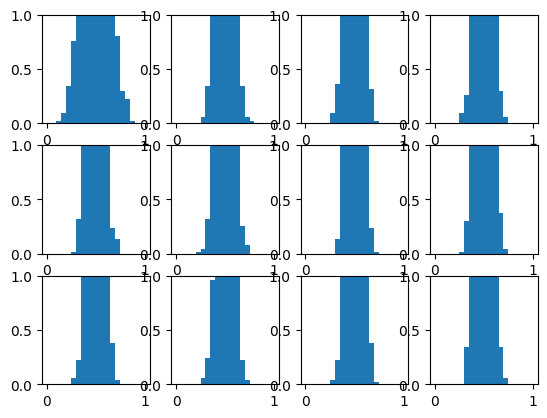

-- Tanh


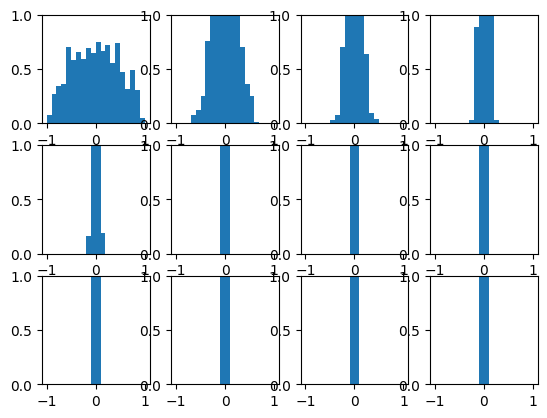

-- ReLU


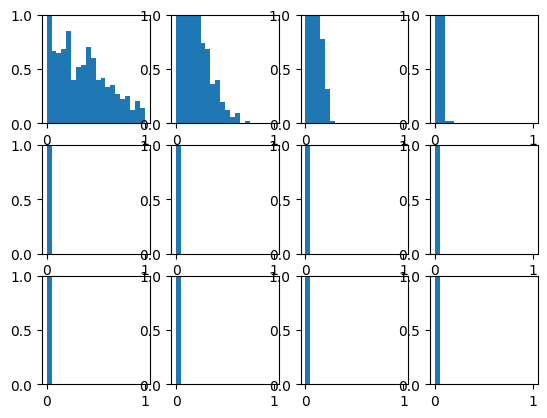

Xavierの初期化
-- Sigmoid


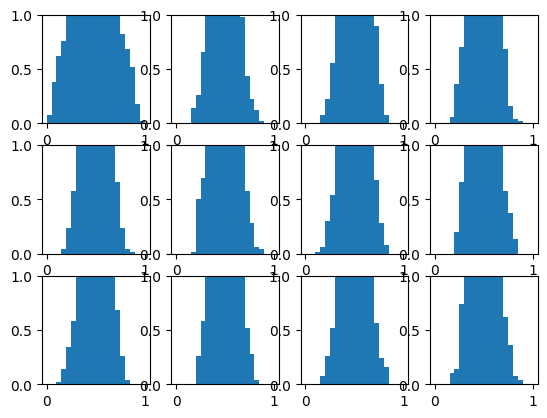

-- Tanh


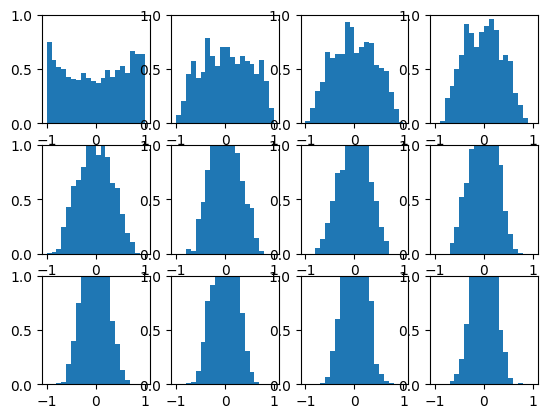

--ReLU


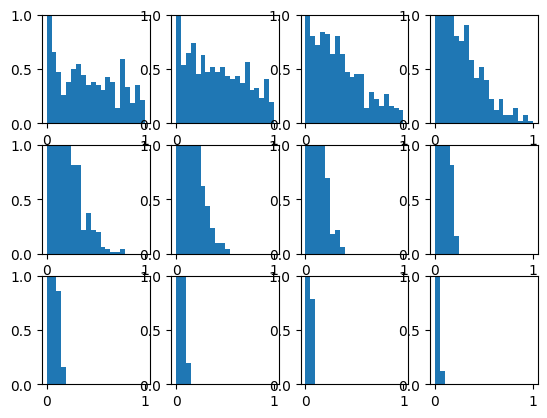

Kaiming
-- ReLU


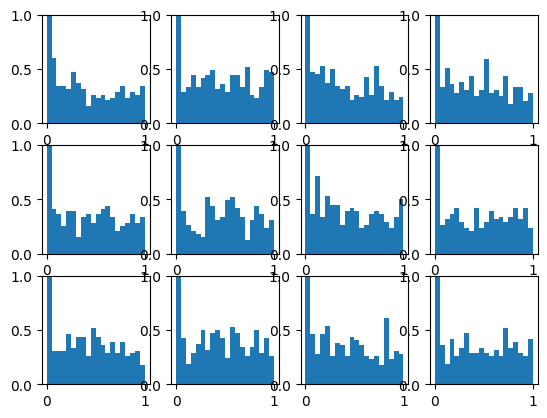

In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.utils as util
import random
from typing import Callable, List
import matplotlib.pyplot as plt
n_layers = 12
in_features = 1000
out_features = 1000
activation_sigmoid = nn.Sigmoid()
activation_tanh = nn.Tanh()
activation_relu = nn.ReLU()
class CustomInitNet(nn.Module): # 実験用ネットワーク
    def __init__(
        self,
        n_layers: int,
        in_features: int,
        out_features: int,
        activation: nn.Module,
        func_init_weight: Callable[[torch.Tensor], None],
    ) -> None:
        super().__init__()
        self._fc = []
        for i in range(n_layers):
            self._fc.append(nn.Linear(in_features, out_features))
            func_init_weight(self._fc[i].weight.data)
            nn.init.zeros_(self._fc[i].bias.data)
        self._activation = activation
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = x
        self._out_list = []
        for i in range(len(self)):
            out = self._fc[i](out)
            out = self._activation(out)
            self._out_list.append(out)
        return out
    def get_layer_out_list(self) -> List[torch.Tensor]:
        return self._out_list
    def __len__(self):
        return len(self._fc)
def visualize(net: CustomInitNet, x_in: torch.Tensor, hist_range: List[int]) -> None:
    out = net.forward(x_in)
    x_out_list = net.get_layer_out_list()
    loss_func = nn.MSELoss()
    loss_value = loss_func(out, torch.zeros_like(out))
    loss_value.backward()
    figure = plt.figure()
    for i in range(len(net)):
        ax = figure.add_subplot(3, 4, i+1)
        ax.hist(x_out_list[i].detach().numpy(), bins=20, range=hist_range, density=True)
        ax.set_xlim
        ax.set_ylim([0, 1])
    plt.show()
print("普通の初期化")
func_init_weight = lambda weight: (
    nn.init.uniform_(weight, -1.0 / np.sqrt(in_features), 1.0 / np.sqrt(in_features))
)
print("-- Sigmoid")
net = CustomInitNet(
    n_layers=n_layers, in_features=in_features, out_features=out_features,
    activation=activation_sigmoid,
    func_init_weight=func_init_weight,
)
x_in = torch.empty((in_features,)).normal_(0, 1).requires_grad_()
visualize(net, x_in, hist_range=[0, 1])
print("-- Tanh")
net = CustomInitNet(
    n_layers=n_layers, in_features=in_features, out_features=out_features,
    activation=activation_tanh,
    func_init_weight=func_init_weight,
)
x_in = torch.empty((in_features,)).normal_(0, 1)
visualize(net, x_in, hist_range=[-1, 1])
print("-- ReLU")
net = CustomInitNet(
    n_layers=n_layers, in_features=in_features, out_features=out_features,
    activation=activation_relu,
    func_init_weight=func_init_weight,
)
x_in = torch.empty((in_features,)).normal_(0, 1)
visualize(net, x_in, hist_range=[0, 1])
print("Xavierの初期化")
'''
func_init_weight = lambda weight: (
    nn.init.uniform_(
        weight,
        -np.sqrt(6 / (in_features + out_features)),
        np.sqrt(6 / (in_features + out_features)),
    )
)
'''
func_init_weight = lambda weight: (
    nn.init.xavier_uniform_(weight)
)
print("-- Sigmoid")
net = CustomInitNet(
    n_layers=n_layers, in_features=in_features, out_features=out_features,
    activation=activation_sigmoid,
    func_init_weight=func_init_weight,
)
x_in = torch.empty((in_features,)).normal_(0, 1)
visualize(net, x_in, hist_range=[0, 1])
print("-- Tanh")
net = CustomInitNet(
    n_layers=n_layers, in_features=in_features, out_features=out_features,
    activation=activation_tanh,
    func_init_weight=func_init_weight,
)
x_in = torch.empty((in_features,)).normal_(0, 1)
visualize(net, x_in, hist_range=[-1, 1])
print("--ReLU")
net = CustomInitNet(
    n_layers=n_layers, in_features=in_features, out_features=out_features,
    activation=activation_relu,
    func_init_weight=func_init_weight,
)
x_in = torch.empty((in_features,)).normal_(0, 1)
visualize(net, x_in, hist_range=[0, 1])
print("Kaiming")
func_init_weight = lambda weight: (
    nn.init.kaiming_normal_(weight, mode="fan_in", nonlinearity="relu")
)
print("-- ReLU")
net = CustomInitNet(
    n_layers=n_layers, in_features=in_features, out_features=out_features,
    activation=activation_relu,
    func_init_weight=func_init_weight,
)
x_in = torch.empty((in_features,)).normal_(0, 1).requires_grad_()
visualize(net, x_in, hist_range=[0, 1])

# 課題

Pix2pixによるカラー化において、自分で準備、もしくは作成した白黒画像を実際にカラー化しなさい
- 本内容で得られたコード、学習結果を利用してよい
- 解像度は問わない

# 課題2

CycleGANを実装しなさい
- 検索すると様々な実装がなされている
- Colaboratory上に実装し、例えばウマをシマウマに変更するなどの効果を確認しなさい

https://github.com/DH-rgb/cycle-gan

https://colab.research.google.com/github/junyanz/pytorch-CycleGAN-and-pix2pix/blob/master/CycleGAN.ipynb

などがある

# 課題3

Conditional GANを用いて、CelebAを用い、CelebAが持つ様々な属性値で画像を抽出、これを属性値の条件として狙った画像を生成させなさい
- 例えば、9) 黒髪かどうか、10) ブロンドヘアーかどうか、12) ブラウンヘアーかどうか、16) 眼鏡をかけているかどうか、21) 男性か女性か、32) 笑っているかどうか、について画像を抽出する
- 画像枚数を揃えて、学習させる
- 狙ったクラスの画像が生成できることを確認する

例えば、以下を参考にColaboratoryで実装しなさい

http://cedro3.com/ai/pytorch-conditional-gan/


# 課題4

InfoGANを実装しなさい

# 課題5

StackGANについて、学習済みモデルを用い、実際に文章から画像を生成しなさい
- これに関しては、Diffusion Networkを用いた高品位な文章を用いた画像生成手法と学習済みモデルが実現・提供されている

- 参考として、逆にイメージから文章を作成する手法をImage Captioningと呼び、GANを用いずともモデルを構築できる
  - CNNでEncodeし、LSTMで文章を構築させる手法がある

# 参考文献

- Goodfellow, I. et al. (2014). "Generative Adversarial Nets." NeurIPS 2014.
- Radford, A. et al. (2016). "Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks." ICLR 2016.
- Isola, P. et al. (2017). "Image-to-Image Translation with Conditional Adversarial Networks." CVPR 2017.
- Zhu, J.-Y. et al. (2017). "Unpaired Image-to-Image Translation using Cycle-Consistent Adversarial Networks." ICCV 2017.
- Karras, T. et al. (2018). "Progressive Growing of GANs for Improved Quality, Stability, and Variation." ICLR 2018.
- Karras, T. et al. (2019). "A Style-Based Generator Architecture for Generative Adversarial Networks." CVPR 2019.
- Heusel, M. et al. (2017). "GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium." NeurIPS 2017.
- Glorot, X. & Bengio, Y. (2010). "Understanding the difficulty of training deep feedforward neural networks." AISTATS 2010.
- He, K. et al. (2015). "Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification." ICCV 2015.
- Arjovsky, M. et al. (2017). "Wasserstein Generative Adversarial Networks." ICML 2017.
- Mirza, M. & Osindero, S. (2014). "Conditional Generative Adversarial Nets." arXiv:1411.1784.
- Chen, X. et al. (2016). "InfoGAN: Interpretable Representation Learning by Information Maximizing Generative Adversarial Nets." NeurIPS 2016.
- Zhang, H. et al. (2017). "StackGAN: Text to Photo-realistic Image Synthesis with Stacked Generative Adversarial Networks." ICCV 2017.
- Ronneberger, O. et al. (2015). "U-Net: Convolutional Networks for Biomedical Image Segmentation." MICCAI 2015.
- Salimans, T. et al. (2016). "Improved Techniques for Training GANs." NeurIPS 2016.
- Bińkowski, M. et al. (2018). "Demystifying MMD GANs." ICLR 2018.
- Kynkäänniemi, T. et al. (2019). "Improved Precision and Recall Metric for Assessing Generative Models." NeurIPS 2019.
- Parmar, G. et al. (2022). "On Aliased Resizing and Surprising Subtleties in GAN Evaluation." CVPR 2022.
- Naeem, M. F. et al. (2020). "Reliable Fidelity and Diversity Metrics for Generative Models." ICML 2020.